# Transfer Learning Assignment

### ResNet-50 vs DenseNet-121 on CalTech-101  
**Course:** Deep Learning (DATA302)  
**University:** Vidyashilp University  




Assumptions & Justifications

As permitted by the assignment instructions, the following assumptions are made:

1. **Label Smoothing (ε = 0.1)** added to `CrossEntropyLoss` to penalise overconfident predictions — important for CalTech-101's small per-class sample count (~91 images/class on average).

2. **Light Data Augmentation** (`RandomHorizontalFlip`, `ColorJitter`) applied during training only — standard practice that does not conflict with the required ImageNet transforms; reduces overfitting on small datasets.

3. **Adaptive Fine-tuning via gradient hooks** — PyTorch does not support per-channel freezing at the parameter level. A backward hook is registered on the target `Conv2d`'s `.weight` tensor that zeroes gradients for the bottom 75% of filters before the optimiser step. This is the canonical PyTorch approach.

4. **DenseNet-121 AFT target layer** — Importance is measured on the **last DenseLayer's `conv2`** (out_channels = 32, the growth rate) rather than the full `denseblock4` output. No single `Conv2d` in `denseblock4` has 1024 output channels — that value arises from concatenation of 16 × 32 channel outputs. Targeting `conv2` of the last `DenseLayer` is architecturally correct and produces a valid gradient mask.

5. **100 mini-batches** (~3,200 images) used for importance score computation — sufficient to rank filters reliably while keeping pre-training time tractable.

6. **Early Stopping patience = 7 > ReduceLROnPlateau patience = 4** — ensures the scheduler gets at least one LR reduction window before training terminates. Best checkpoint is always restored.

In [1]:
# ─── 1. IMPORTS & REPRODUCIBILITY ────────────────────────────────────────────
import os, copy, time, random
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [2]:
# ── Reproducibility seed ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

Running on: cuda


In [3]:
# ─── 2. DATASET PREPARATION ──────────────────────────────────────
DATA_DIR    = "./data"
BATCH_SIZE  = 32
NUM_WORKERS = 4 if torch.cuda.is_available() else 0

# ImageNet normalisation constants (required because models pre-trained on ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [4]:
# ── 2a. Transform pipelines ──
# Training: resize→center-crop (as specified) + light augmentation
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
# Validation / Test: deterministic
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [6]:
import PIL
from torchvision import transforms

class RGB_Wrapper(torch.utils.data.Dataset):
    """Wraps Caltech101 dataset to ensure all images are RGB before applying transforms."""
    
    def __init__(self, base_dataset, transform=None):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        
        # Ensure image is a PIL Image
        if not isinstance(img, PIL.Image.Image):
            if isinstance(img, torch.Tensor):
                img = transforms.ToPILImage()(img.cpu())
            else:
                # Fallback: try to convert directly
                img = transforms.ToPILImage()(np.array(img))
        
        # Convert to RGB (handles grayscale images)
        img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)
            
        return img, label

## Section 2 — Dataset Preparation

### CalTech-101 Overview
- **101 object categories** (+ background clutter category)
- **~9,146 images** total; 40–800 images per class (heavy long-tail distribution)
- Images are natural photographs at varying resolutions

### Data Split Strategy
Stratified split **per class** to preserve class-ratio balance:

| Split | Fraction | Approx Images |
|---|---|---|
| Train | 70% | ~6,402 |
| Validation | 10% | ~914 |
| Test | 20% | ~1,830 |

### Preprocessing Pipeline

| Step | Train | Val / Test |
|---|---|---|
| Resize | 256×256 | 256×256 |
| CenterCrop | 224×224 | 224×224 |
| RandomHorizontalFlip (p=0.5) | ✅ | ❌ |
| ColorJitter (brightness±0.2) | ✅ | ❌ |
| ToTensor + Normalize (ImageNet μ/σ) | ✅ | ✅ |

**Normalisation constants** (ImageNet statistics):  
`μ = [0.485, 0.456, 0.406]`  `σ = [0.229, 0.224, 0.225]`

> **Note:** CalTech-101 contains grayscale images. The `torchvision` loader handles this via `transform` — grayscale images are broadcast to 3 channels automatically when loaded with standard transforms.


In [7]:
# ── 2b. Dataset Loading & Stratified Split ─────────────────────────────

print("Loading Caltech-101 dataset...")

# Load dataset once (no transforms) to access labels
_raw = datasets.Caltech101(root=DATA_DIR, download=True, transform=None)

NUM_CLASSES = len(_raw.categories)
CLASS_NAMES = _raw.categories

print(f"Number of classes : {NUM_CLASSES}")
print(f"Total samples     : {len(_raw)}")


# Extract labels for stratified splitting
labels_all = [_raw[i][1] for i in range(len(_raw))]


# Create class-wise index mapping
from collections import defaultdict
class_to_idx = defaultdict(list)

for idx, lbl in enumerate(labels_all):
    class_to_idx[lbl].append(idx)


# Stratified split: 70% train, 10% val, 20% test
rng = random.Random(SEED)

train_idx, val_idx, test_idx = [], [], []

for cls in sorted(class_to_idx):
    idxs = class_to_idx[cls]
    rng.shuffle(idxs)

    n = len(idxs)
    n_train = int(0.70 * n)
    n_val   = int(0.10 * n)

    train_idx.extend(idxs[:n_train])
    val_idx.extend(idxs[n_train:n_train + n_val])
    test_idx.extend(idxs[n_train + n_val:])


print("\nSplit Summary:")
print(f"Train set      : {len(train_idx)} samples")
print(f"Validation set : {len(val_idx)} samples")
print(f"Test set       : {len(test_idx)} samples")


# ── DataLoader Utility ────────────────────────────────────────────────

def make_loader(indices, transform, shuffle):
    """
    Create DataLoader for a subset of Caltech101 dataset.
    Ensures all images are converted to RGB before applying transforms.
    """
    base_dataset = datasets.Caltech101(root=DATA_DIR, download=False, transform=None)
    dataset = RGB_Wrapper(base_dataset, transform=transform)
    subset = Subset(dataset, indices)

    return DataLoader(
        subset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )


# Create DataLoaders
train_loader = make_loader(train_idx, train_tf, shuffle=True)
val_loader   = make_loader(val_idx,   eval_tf,  shuffle=False)
test_loader  = make_loader(test_idx,  eval_tf,  shuffle=False)


# ── Sanity Check ──────────────────────────────────────────────────────

images, labels = next(iter(train_loader))

print("\nSanity Check:")
print(f"Batch shape   : {images.shape}")
print(f"Label shape   : {labels.shape}")

Loading Caltech-101 dataset...


100%|██████████| 137M/137M [00:03<00:00, 39.9MB/s] 


Number of classes : 101
Total samples     : 8677

Split Summary:
Train set      : 6026 samples
Validation set : 820 samples
Test set       : 1831 samples

Sanity Check:
Batch shape   : torch.Size([32, 3, 224, 224])
Label shape   : torch.Size([32])


## Section 3 — Model Architecture & Transfer Learning Setup

### 3.1 ResNet-50 — Residual Learning

The core innovation of ResNet is the **identity shortcut connection**:

$$H(x) = F(x) + x$$

Where:
- $x$ = input to a residual block
- $F(x)$ = the residual mapping learned by the stacked layers (two/three convolutions)
- $H(x)$ = the desired underlying mapping

If the optimal solution is close to identity, $F(x) \rightarrow 0$ is easier to learn than fitting $H(x) \rightarrow x$ directly.  
This design **solves vanishing gradients** by allowing gradient flow directly through the shortcut path.

**Architecture:** 4 stages (`layer1`–`layer4`), each with Bottleneck blocks (1×1 → 3×3 → 1×1 convolutions).  
**Head modification:** `fc (1000)` → `Dropout(0.4) + Linear(2048, 101)`  
**Total parameters:** ~25.6 M

---

### 3.2 DenseNet-121 — Dense Connectivity

Every layer receives feature maps from **all preceding layers** via concatenation:

$$x_\ell = H_\ell([x_0, x_1, \ldots, x_{\ell-1}])$$

Where $[\cdot]$ denotes channel-wise concatenation. This leads to:
- **Feature reuse** — earlier features are always accessible to later layers
- **Implicit deep supervision** — every layer directly contributes to final output
- **Parameter efficiency** — no need to re-learn features from scratch

**Architecture:** 4 dense blocks with growth rate $k = 32$ (each DenseLayer adds 32 channels).  
`denseblock4`: 16 DenseLayers → output = 512 + 16×32 = **1024 concatenated channels**  
**Head modification:** `classifier (1000)` → `Dropout(0.4) + Linear(1024, 101)`  
**Total parameters:** ~7.0 M (~3.6× lighter than ResNet-50)

---

### 3.3 Why Transfer Learning?

Both models are pre-trained on **ImageNet** (1.2M images, 1000 classes). The lower layers encode universal visual features (edges, textures, colours) that transfer directly to any natural-image domain. Only the upper layers and the new classification head need adaptation to CalTech-101.


In [30]:
# ─── MODEL LOADING (from saved checkpoints) ──────────────────────────────────
import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_path = "/kaggle/input/models/pruthvirajshinder/model/pytorch/default/1/all files/"

# ── Architecture builders (must match training-time architecture) ──
def build_resnet50(num_classes):
    model = models.resnet50(weights=None)
    in_feat = model.fc.in_features          # 2048
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, num_classes)
    )
    return model

def build_densenet121(num_classes):
    model = models.densenet121(weights=None)
    in_feat = model.classifier.in_features  # 1024
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, num_classes)
    )
    return model

# ── Load checkpoints ──
resnet_ckpt       = torch.load(base_path + "resnet50_finetuned_full_checkpoint.pth",   map_location=DEVICE)
densenet_ckpt     = torch.load(base_path + "densenet121_finetuned_full_checkpoint.pth", map_location=DEVICE)
resnet_adap_ckpt  = torch.load(base_path + "resnet50_adaptive_full_checkpoint.pth",    map_location=DEVICE)
densenet_adap_ckpt= torch.load(base_path + "densenet121_adaptive_full_checkpoint.pth", map_location=DEVICE)

# ── Read NUM_CLASSES from checkpoint (avoids hardcoding) ──
NUM_CLASSES = resnet_ckpt['num_classes']   # should be 101

# ── Build models ──
resnet           = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet         = build_densenet121(NUM_CLASSES).to(DEVICE)
resnet_adaptive  = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet_adaptive= build_densenet121(NUM_CLASSES).to(DEVICE)

# ── Load weights ──
resnet.load_state_dict(resnet_ckpt['model_state_dict'])
densenet.load_state_dict(densenet_ckpt['model_state_dict'])
resnet_adaptive.load_state_dict(resnet_adap_ckpt['model_state_dict'])
densenet_adaptive.load_state_dict(densenet_adap_ckpt['model_state_dict'])

# ── Set eval mode ──
resnet.eval()
densenet.eval()
resnet_adaptive.eval()
densenet_adaptive.eval()

print(f" All 4 models loaded on {DEVICE}  |  NUM_CLASSES = {NUM_CLASSES}")
print(f"   ResNet-50 head     : {resnet.fc}")
print(f"   DenseNet-121 head  : {densenet.classifier}")

 All 4 models loaded on cuda  |  NUM_CLASSES = 101
   ResNet-50 head     : Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=2048, out_features=101, bias=True)
)
   DenseNet-121 head  : Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1024, out_features=101, bias=True)
)


## Section 4 — Training Utilities

### 4.1 Early Stopping

Early stopping prevents overfitting by halting training when validation loss stops improving.

**Configuration:**
- `patience = 7` epochs — larger than `ReduceLROnPlateau` patience (4) so LR scheduler gets ≥1 reduction window first
- `min_delta = 1e-4` — ignores sub-noise fluctuations
- Monitors **validation loss** (more sensitive than accuracy to overfitting onset)
- Automatically restores best checkpoint weights

### 4.2 Hyperparameter Justifications

| Hyperparameter | Value | Justification |
|---|---|---|
| Optimiser | Adam | Handles mixed LR groups without manual momentum tuning |
| Backbone LR | 1e-4 (FT) / 5e-5 (AFT) | Low LR avoids catastrophic forgetting of pretrained features |
| Head LR | 1e-3 | Randomly initialised head needs aggressive updates |
| Weight Decay | 1e-4 | L2 regularisation to mitigate overfitting |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=4) | Adaptive — halves LR when val_loss plateaus |
| Batch Size | 32 | Stable gradients; fits in GPU VRAM |
| Max Epochs | 25 | Upper cap; Early Stopping typically triggers earlier |
| Label Smoothing | ε = 0.1 | Prevents overconfident predictions on small per-class sets |
| Dropout | p = 0.4 | Regularises the new classification head |


In [9]:
# ─── 4. Training Utilities ────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Performs one training epoch."""
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += outputs.argmax(1).eq(labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluates model on validation/test set."""
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        preds = outputs.argmax(1)

        total_loss += loss.item() * images.size(0)
        total_correct += preds.eq(labels).sum().item()
        total_samples += images.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)


# ─── Early Stopping ───────────────────────────────────────────────────

class EarlyStopping:
    """
    Stops training when validation loss stops improving.
    """

    def __init__(self, patience=7, min_delta=1e-4, restore_best=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best

        self.best_loss = float('inf')
        self.best_weights = None
        self.counter = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

        return False

    def restore(self, model):
        if self.restore_best and self.best_weights is not None:
            model.load_state_dict(self.best_weights)
        return model


# ─── Training Loop ────────────────────────────────────────────────────

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, device, num_epochs=25, label="model",
                es_patience=7, es_min_delta=1e-4):

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    early_stopping = EarlyStopping(patience=es_patience, min_delta=es_min_delta)

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        # Scheduler step
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - start_time
        lr = optimizer.param_groups[0]['lr']

        print(f"[{label}] Epoch {epoch:02d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f} | "
              f"LR: {lr:.1e} | Time: {elapsed:.1f}s")

        # Early stopping check
        if early_stopping(val_loss, model):
            print(f"[{label}] Early stopping triggered.")
            break

    # Restore best model
    model = early_stopping.restore(model)

    print(f"[{label}] Training completed. Best Val Loss: {early_stopping.best_loss:.4f}")

    return model, history

## Section 5 — Fine-Tuning Strategy 1: Standard Fine-Tuning

### Approach
Freeze all backbone weights, then **unfreeze the top convolutional blocks** and train with differential learning rates.

**ResNet-50:** Unfreeze `layer3`, `layer4`, and `fc`  
**DenseNet-121:** Unfreeze `denseblock3`, `transition3`, `denseblock4`, `norm5`, and `classifier`

### Rationale for Layer Selection
- **Frozen lower layers** (`layer1`, `layer2` / `denseblock1`, `denseblock2`): encode universal low-level features (edges, blobs, textures) that transfer perfectly to any natural image domain
- **Unfrozen upper layers**: encode high-level, task-specific semantic features that need adaptation from ImageNet (1000 classes) to CalTech-101 objects

### Differential Learning Rate
- Backbone: `α = 1×10⁻⁴` — small to avoid catastrophic forgetting
- Head: `α = 1×10⁻³` — larger since weights are randomly initialised


In [10]:
# ─── 5. STRATEGY 1 – STANDARD FINE-TUNING ────────────────────────────────────

def setup_finetune_resnet50(model, lr_bb=1e-4, lr_hd=1e-3):
    for p in model.parameters():
        p.requires_grad = False
    for name, p in model.named_parameters():
        if any(s in name for s in ['layer3', 'layer4', 'fc']):
            p.requires_grad = True
    bb_params = [p for n, p in model.named_parameters() if p.requires_grad and 'fc' not in n]
    hd_params = [p for n, p in model.named_parameters() if p.requires_grad and 'fc' in n]
    return optim.Adam([{'params': bb_params, 'lr': lr_bb, 'weight_decay': 1e-4},
                        {'params': hd_params, 'lr': lr_hd, 'weight_decay': 1e-4}])

def setup_finetune_densenet121(model, lr_bb=1e-4, lr_hd=1e-3):
    for p in model.parameters():
        p.requires_grad = False
    unfreeze_keys = ['denseblock3', 'transition3', 'denseblock4', 'norm5', 'classifier']
    for name, p in model.named_parameters():
        if any(s in name for s in unfreeze_keys):
            p.requires_grad = True
    bb_params = [p for n, p in model.named_parameters()
                 if p.requires_grad and 'classifier' not in n]
    hd_params = [p for n, p in model.named_parameters()
                 if p.requires_grad and 'classifier' in n]
    return optim.Adam([{'params': bb_params, 'lr': lr_bb, 'weight_decay': 1e-4},
                        {'params': hd_params, 'lr': lr_hd, 'weight_decay': 1e-4}])

In [11]:
# ─── Apply Strategy 1: ResNet-50 ───────────────────────────────────

print("\nApplying Standard Fine-Tuning (ResNet-50)...")

# Build model
resnet_ft = build_resnet50(NUM_CLASSES).to(DEVICE)

# Apply fine-tuning setup
optimizer_rn_ft = setup_finetune_resnet50(resnet_ft)

# ─── Print trainable layers (simple view) ─────────────────────────
print("\nTrainable Layers:\n")

for name, param in resnet_ft.named_parameters():
    if param.requires_grad:
        print(name)


# ─── Parameter summary ────────────────────────────────────────────
total_params = sum(p.numel() for p in resnet_ft.parameters())
trainable_params = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)

print("\nParameter Summary:")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Trainable %      : {trainable_params/total_params*100:.2f}%")


Applying Standard Fine-Tuning (ResNet-50)...

Trainable Layers:

layer3.0.conv1.weight
layer3.0.bn1.weight
layer3.0.bn1.bias
layer3.0.conv2.weight
layer3.0.bn2.weight
layer3.0.bn2.bias
layer3.0.conv3.weight
layer3.0.bn3.weight
layer3.0.bn3.bias
layer3.0.downsample.0.weight
layer3.0.downsample.1.weight
layer3.0.downsample.1.bias
layer3.1.conv1.weight
layer3.1.bn1.weight
layer3.1.bn1.bias
layer3.1.conv2.weight
layer3.1.bn2.weight
layer3.1.bn2.bias
layer3.1.conv3.weight
layer3.1.bn3.weight
layer3.1.bn3.bias
layer3.2.conv1.weight
layer3.2.bn1.weight
layer3.2.bn1.bias
layer3.2.conv2.weight
layer3.2.bn2.weight
layer3.2.bn2.bias
layer3.2.conv3.weight
layer3.2.bn3.weight
layer3.2.bn3.bias
layer3.3.conv1.weight
layer3.3.bn1.weight
layer3.3.bn1.bias
layer3.3.conv2.weight
layer3.3.bn2.weight
layer3.3.bn2.bias
layer3.3.conv3.weight
layer3.3.bn3.weight
layer3.3.bn3.bias
layer3.4.conv1.weight
layer3.4.bn1.weight
layer3.4.bn1.bias
layer3.4.conv2.weight
layer3.4.bn2.weight
layer3.4.bn2.bias
layer3.4.

In [12]:
# ─── Apply Strategy 1: DenseNet-121 ───────────────────────────────

print("\nApplying Standard Fine-Tuning (DenseNet-121)...")

# Build model
densenet_ft = build_densenet121(NUM_CLASSES).to(DEVICE)

# Apply fine-tuning setup
optimizer_dn_ft = setup_finetune_densenet121(densenet_ft)

# ─── Print trainable layers ───────────────────────────────────────
print("\nTrainable Layers:\n")

for name, param in densenet_ft.named_parameters():
    if param.requires_grad:
        print(name)


# ─── Parameter summary ────────────────────────────────────────────
total_params = sum(p.numel() for p in densenet_ft.parameters())
trainable_params = sum(p.numel() for p in densenet_ft.parameters() if p.requires_grad)

print("\nParameter Summary:")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Trainable %      : {trainable_params/total_params*100:.2f}%")


Applying Standard Fine-Tuning (DenseNet-121)...

Trainable Layers:

features.denseblock3.denselayer1.norm1.weight
features.denseblock3.denselayer1.norm1.bias
features.denseblock3.denselayer1.conv1.weight
features.denseblock3.denselayer1.norm2.weight
features.denseblock3.denselayer1.norm2.bias
features.denseblock3.denselayer1.conv2.weight
features.denseblock3.denselayer2.norm1.weight
features.denseblock3.denselayer2.norm1.bias
features.denseblock3.denselayer2.conv1.weight
features.denseblock3.denselayer2.norm2.weight
features.denseblock3.denselayer2.norm2.bias
features.denseblock3.denselayer2.conv2.weight
features.denseblock3.denselayer3.norm1.weight
features.denseblock3.denselayer3.norm1.bias
features.denseblock3.denselayer3.conv1.weight
features.denseblock3.denselayer3.norm2.weight
features.denseblock3.denselayer3.norm2.bias
features.denseblock3.denselayer3.conv2.weight
features.denseblock3.denselayer4.norm1.weight
features.denseblock3.denselayer4.norm1.bias
features.denseblock3.dens

## Section 6 — Fine-Tuning Strategy 2: Adaptive Fine-Tuning (Filter Importance Ranking)

### Algorithm Overview

This custom strategy selectively fine-tunes only the most discriminative filters in the last convolutional block:

**Step (a):** Freeze all backbone weights.

**Step (b):** Forward-pass 100 mini-batches (~3,200 training images) through the frozen model.

**Step (c):** At the output of the target conv layer, record the **mean absolute activation per channel**:
$$\text{Importance}[c] = \frac{1}{N} \sum_{b,h,w} |A_{b,c,h,w}|$$

**Step (d):** Rank all filters by importance score; select top **25%** (highest mean activation).

**Step (e):** Unfreeze the last block; register a **backward hook** on the target `Conv2d` that zeroes gradients for the bottom 75% of filters:
$$g_c \leftarrow g_c \cdot \mathbf{1}[c \in \text{top-25\%}]$$

### Architecture-Specific Target Layers

| Model | Target Layer | Output Channels | Reason |
|---|---|---|---|
| ResNet-50 | Last `Conv2d` in `layer4` with `out_channels=2048` | 2048 | Single conv produces full block output |
| DenseNet-121 | `conv2` of last `DenseLayer` in `denseblock4` | 32 (growth rate) | No single conv has 1024 outputs; block output is a concatenation |

> **Key Fix:** DenseNet's `denseblock4` output (1024 channels) is a *concatenation* of 16 DenseLayers each contributing 32 channels. No single `Conv2d` produces 1024 channels, so the hook must target `conv2` of the **last DenseLayer** specifically.

### Rationale
Filters with high mean absolute activation are already strongly responding to CalTech-101 features under the frozen ImageNet weights — adapting them first yields maximum information gain per trainable parameter.


In [11]:
# --- 6. STRATEGY 2: ADAPTIVE FINE-TUNING (FILTER IMPORTANCE RANKING) ---

NUM_IMPORTANCE_BATCHES = 100


def _compute_importance(model, hook_target, data_loader, device,
                        n_batches=NUM_IMPORTANCE_BATCHES):
    """Compute channel-wise importance using mean absolute activation."""
    model.eval()
    store = []

    def _hook(mod, inp, out):
        store.append(out.detach().abs().mean(dim=[0, 2, 3]).cpu())

    handle = hook_target.register_forward_hook(_hook)

    with torch.no_grad():
        for i, (imgs, _) in enumerate(data_loader):
            if i >= n_batches:
                break
            model(imgs.to(device))

    handle.remove()

    importance = torch.stack(store).mean(0).numpy()
    return importance


def compute_importance_resnet50(model, loader, device):
    return _compute_importance(model, model.layer4, loader, device)


def compute_importance_densenet121(model, loader, device):
    """
    DenseNet fix:
    Use last DenseLayer's conv2 (growth rate channels = 32)
    """
    last_denselayer = list(model.features.denseblock4.children())[-1]
    return _compute_importance(model, last_denselayer.conv2, loader, device)


def _register_gradient_mask(conv_layer, top_filter_set, n_out, device):
    """Mask gradients so only selected filters are updated."""
    mask = torch.zeros(n_out, dtype=torch.float32, device=device)
    for idx in top_filter_set:
        mask[idx] = 1.0

    def _hook(grad):
        return grad * mask.view(-1, 1, 1, 1)

    return conv_layer.weight.register_hook(_hook)


def setup_adaptive_resnet50(model, importance, top_frac=0.25,
                           lr_bb=5e-5, lr_hd=1e-3):
    """
    Adaptive fine-tuning for ResNet-50
    """
    n_filters = len(importance)
    k = max(1, int(n_filters * top_frac))
    top_set = set(np.argsort(importance)[-k:].tolist())

    print(f"ResNet-50 AFT | Filters: {n_filters} | Top {k}")

    for p in model.parameters():
        p.requires_grad = False

    for name, p in model.named_parameters():
        if 'layer4' in name or 'fc' in name:
            p.requires_grad = True

    target_conv = None
    for mod in model.layer4.modules():
        if isinstance(mod, nn.Conv2d) and mod.weight.shape[0] == n_filters:
            target_conv = mod

    hooks = []
    if target_conv is not None:
        hooks.append(_register_gradient_mask(target_conv, top_set, n_filters, DEVICE))
    else:
        print("Warning: target conv not found; full layer4 will be trained.")

    bb_params = [p for n, p in model.named_parameters()
                 if p.requires_grad and 'fc' not in n]
    hd_params = [p for n, p in model.named_parameters()
                 if p.requires_grad and 'fc' in n]

    optimizer = optim.Adam([
        {'params': bb_params, 'lr': lr_bb, 'weight_decay': 1e-4},
        {'params': hd_params, 'lr': lr_hd, 'weight_decay': 1e-4}
    ])

    return optimizer, hooks


def setup_adaptive_densenet121(model, importance, top_frac=0.25,
                              lr_bb=5e-5, lr_hd=1e-3):
    """
    Adaptive fine-tuning for DenseNet-121 using last DenseLayer conv2
    """
    n_filters = len(importance)   # should be 32
    k = max(1, int(n_filters * top_frac))
    top_set = set(np.argsort(importance)[-k:].tolist())

    print(f"DenseNet-121 AFT | Filters: {n_filters} | Top {k}")

    for p in model.parameters():
        p.requires_grad = False

    for name, p in model.named_parameters():
        if any(s in name for s in ['denseblock4', 'norm5', 'classifier']):
            p.requires_grad = True

    last_denselayer = list(model.features.denseblock4.children())[-1]
    target_conv = last_denselayer.conv2

    hooks = []
    hooks.append(_register_gradient_mask(target_conv, top_set, n_filters, DEVICE))

    print(f"Gradient mask applied on layer with shape {list(target_conv.weight.shape)}")

    bb_params = [p for n, p in model.named_parameters()
                 if p.requires_grad and 'classifier' not in n]
    hd_params = [p for n, p in model.named_parameters()
                 if p.requires_grad and 'classifier' in n]

    optimizer = optim.Adam([
        {'params': bb_params, 'lr': lr_bb, 'weight_decay': 1e-4},
        {'params': hd_params, 'lr': lr_hd, 'weight_decay': 1e-4}
    ])

    return optimizer, hooks

In [23]:
# ─── EXECUTE ADAPTIVE SETUP + PRINT SUMMARIES FOR ALL MODELS ─────────────
print(" Computing importance scores and setting up Adaptive Fine-Tuning...\n")

# Compute importance (using the already-loaded adaptive models)
importance_resnet_adaptive   = compute_importance_resnet50(resnet_adaptive, train_loader, DEVICE)
importance_densenet_adaptive = compute_importance_densenet121(densenet_adaptive, train_loader, DEVICE)

print(" Importance scores computed for both models.\n")

# Setup Adaptive Fine-Tuning (applies freezing + gradient masks)
optimizer_resnet_adap,   hooks_resnet   = setup_adaptive_resnet50(resnet_adaptive,   importance_resnet_adaptive)
optimizer_densenet_adap, hooks_densenet = setup_adaptive_densenet121(densenet_adaptive, importance_densenet_adaptive)

print("\n" + "="*80)
print(" Adaptive Fine-Tuning successfully set up on both models!")
print("="*80)

# ─── Print beautiful summaries for ALL 4 models ───────────────────────
print_adaptive_summary(resnet_ft,          importance=None,          model_name="ResNet-50 (Standard Full Fine-Tuning)")
print_adaptive_summary(densenet_ft,        importance=None,          model_name="DenseNet-121 (Standard Full Fine-Tuning)")
print_adaptive_summary(resnet_adaptive,    importance=importance_resnet_adaptive,   model_name="ResNet-50 (Adaptive Fine-Tuning)")
print_adaptive_summary(densenet_adaptive,  importance=importance_densenet_adaptive, model_name="DenseNet-121 (Adaptive Fine-Tuning)")

print("\n All summaries generated. You can now proceed to training if needed.")

 Computing importance scores and setting up Adaptive Fine-Tuning...

 Importance scores computed for both models.

ResNet-50 AFT | Filters: 2048 | Top 512
DenseNet-121 AFT | Filters: 32 | Top 8
Gradient mask applied on layer with shape [32, 128, 3, 3]

 Adaptive Fine-Tuning successfully set up on both models!

 ADAPTIVE FINE-TUNING SUMMARY — ResNet-50 (Standard Full Fine-Tuning)
🔹 Standard Full Fine-Tuning (No filter selection applied)

📊 Layer-wise Parameter Status:
Layer Name                                         Status             Params
--------------------------------------------------------------------------------
conv1.weight                                       ❄️  FROZEN          9,408
bn1.weight                                         ❄️  FROZEN             64
bn1.bias                                           ❄️  FROZEN             64
layer1.0.conv1.weight                              ❄️  FROZEN          4,096
layer1.0.bn1.weight                                ❄️  FROZEN 

In [15]:
# --- 7. MAIN TRAINING PIPELINE ---

NUM_EPOCHS = 100
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)

def make_plateau_scheduler(optimizer):
    """
    Version-safe ReduceLROnPlateau scheduler.
    Works across different PyTorch versions.
    """
    try:
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=4,
            verbose=True
        )
    except TypeError:
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=4
        )

results   = {}   # Stores test metrics
histories = {}   # Stores per-epoch history

## Section 7 — Training All Four Models

Four model variants are trained and their best checkpoints saved:

| # | Model | Strategy | Notes |
|---|---|---|---|
| 1 | ResNet-50 | Standard Fine-Tuning | layer3 + layer4 + head unfrozen |
| 2 | DenseNet-121 | Standard Fine-Tuning | denseblock3/4 + norm5 + head unfrozen |
| 3 | ResNet-50 | Adaptive Fine-Tuning | Top-25% of layer4 filters, gradient masked |
| 4 | DenseNet-121 | Adaptive Fine-Tuning | Top-25% of last DenseLayer conv2 filters |

Training progress is printed every epoch with format:  
`[Label] Ep XX/25 | TrLoss | TrAcc | VlLoss | VlAcc | F1 | LR | ES=counter/patience | time`


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  ResNet-50  |  Strategy 1: Standard Fine-tuning
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print(" ResNet-50 | Strategy 1: Standard Fine-tuning")
print("━"*65)
resnet_ft   = build_resnet50(NUM_CLASSES).to(DEVICE)
opt_rft     = setup_finetune_resnet50(resnet_ft)
sched_rft   = make_plateau_scheduler(opt_rft)
t_tr, t_tot = count_parameters(resnet_ft)
print(f"  Trainable params: {t_tr:,} / {t_tot:,} total")
resnet_ft, hist_rft = train_model(
    resnet_ft, train_loader, val_loader, criterion,
    opt_rft, sched_rft, DEVICE, NUM_EPOCHS, label="RN50-FT")
torch.save(resnet_ft.state_dict(), "resnet50_finetuned.pth")
histories["ResNet-50 FT"] = hist_rft
#


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ResNet-50 | Strategy 1: Standard Fine-tuning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/btech02_06/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%


  Trainable params: 23,714,981 / 22,270,053 total
[RN50-FT] Ep 01/100 | TrLoss=1.8357 TrAcc=0.7429 | VlLoss=1.1651 VlAcc=0.9293 F1=0.8750 | LR=1.0e-04 | ES=0/7 | 14.4s
[RN50-FT] Ep 02/100 | TrLoss=1.0674 TrAcc=0.9461 | VlLoss=1.0772 VlAcc=0.9390 F1=0.9023 | LR=1.0e-04 | ES=0/7 | 14.1s
[RN50-FT] Ep 03/100 | TrLoss=0.9667 TrAcc=0.9779 | VlLoss=1.0401 VlAcc=0.9476 F1=0.9176 | LR=1.0e-04 | ES=0/7 | 14.0s
[RN50-FT] Ep 04/100 | TrLoss=0.9380 TrAcc=0.9839 | VlLoss=1.0271 VlAcc=0.9561 F1=0.9302 | LR=1.0e-04 | ES=0/7 | 13.9s
[RN50-FT] Ep 05/100 | TrLoss=0.9207 TrAcc=0.9894 | VlLoss=1.0182 VlAcc=0.9561 F1=0.9298 | LR=1.0e-04 | ES=0/7 | 14.3s
[RN50-FT] Ep 06/100 | TrLoss=0.9033 TrAcc=0.9932 | VlLoss=1.0061 VlAcc=0.9598 F1=0.9353 | LR=1.0e-04 | ES=0/7 | 14.4s
[RN50-FT] Ep 07/100 | TrLoss=0.8875 TrAcc=0.9949 | VlLoss=0.9954 VlAcc=0.9598 F1=0.9337 | LR=1.0e-04 | ES=0/7 | 14.1s
[RN50-FT] Ep 08/100 | TrLoss=0.8949 TrAcc=0.9915 | VlLoss=0.9828 VlAcc=0.9646 F1=0.9426 | LR=1.0e-04 | ES=0/7 | 14.0s
[RN50-

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  DenseNet-121  |  Strategy 1: Standard Fine-tuning
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print(" DenseNet-121 | Strategy 1: Standard Fine-tuning")
print("━"*65)
densenet_ft  = build_densenet121(NUM_CLASSES).to(DEVICE)
opt_dft      = setup_finetune_densenet121(densenet_ft)
sched_dft    = make_plateau_scheduler(opt_dft)
t_tr, t_tot = count_parameters(densenet_ft)
print(f"  Trainable params: {t_tr:,} / {t_tot:,} total")
densenet_ft, hist_dft = train_model(
    densenet_ft, train_loader, val_loader, criterion,
    opt_dft, sched_dft, DEVICE, NUM_EPOCHS, label="DN121-FT")
torch.save(densenet_ft.state_dict(), "densenet121_finetuned.pth")
histories["DenseNet-121 FT"] = hist_dft


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DenseNet-121 | Strategy 1: Standard Fine-tuning
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Trainable params: 7,057,381 / 5,627,749 total
[DN121-FT] Ep 01/100 | TrLoss=2.1620 TrAcc=0.6616 | VlLoss=1.1349 VlAcc=0.9293 F1=0.8887 | LR=1.0e-04 | ES=0/7 | 14.2s
[DN121-FT] Ep 02/100 | TrLoss=1.1145 TrAcc=0.9335 | VlLoss=1.0352 VlAcc=0.9488 F1=0.9249 | LR=1.0e-04 | ES=0/7 | 13.4s
[DN121-FT] Ep 03/100 | TrLoss=1.0114 TrAcc=0.9675 | VlLoss=1.0139 VlAcc=0.9463 F1=0.9144 | LR=1.0e-04 | ES=0/7 | 13.5s
[DN121-FT] Ep 04/100 | TrLoss=0.9620 TrAcc=0.9824 | VlLoss=1.0026 VlAcc=0.9598 F1=0.9427 | LR=1.0e-04 | ES=0/7 | 13.5s
[DN121-FT] Ep 05/100 | TrLoss=0.9360 TrAcc=0.9900 | VlLoss=1.0005 VlAcc=0.9561 F1=0.9299 | LR=1.0e-04 | ES=0/7 | 13.9s
[DN121-FT] Ep 06/100 | TrLoss=0.9225 TrAcc=0.9922 | VlLoss=0.9838 VlAcc=0.9634 F1=0.9501 | LR=1.0e-04 | ES=0/7 | 14.0s
[DN121-FT] Ep 07/100 | TrLoss=0.9066 TrAcc=0.9944 | VlLo

In [ ]:
# --- Save FULL CHECKPOINT (recommended) ---

checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': densenet_ft.state_dict(),
    'optimizer_state_dict': opt_dft.state_dict(),
    'scheduler_state_dict': sched_dft.state_dict(),
    'train_history': hist_dft,
    'num_classes': NUM_CLASSES
}

torch.save(checkpoint, "densenet121_finetuned_full_checkpoint.pth")

print("DenseNet-121 full checkpoint saved successfully")

DenseNet-121 full checkpoint saved successfully


In [ ]:
from IPython.display import FileLink

FileLink("densenet121_finetuned_full_checkpoint.pth")

/home/btech02_06/DL/MML_lab_VU_-main/densenet121_finetuned_full_checkpoint.pth

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  ResNet-50  |  Strategy 2: Adaptive Fine-tuning
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print(" ResNet-50 | Strategy 2: Adaptive Fine-tuning (Filter Importance)")
print("━"*65)
resnet_aft  = build_resnet50(NUM_CLASSES).to(DEVICE)
# Step (a+b): freeze all & compute importance
for p in resnet_aft.parameters():
    p.requires_grad = False
print("  Computing filter importance scores …")
imp_rn = compute_importance_resnet50(resnet_aft, train_loader, DEVICE)
# Step (c+d+e): set up optimizer with gradient masking
opt_raft, hooks_rn = setup_adaptive_resnet50(resnet_aft, imp_rn)
sched_raft = make_plateau_scheduler(opt_raft)
resnet_aft, hist_raft = train_model(
    resnet_aft, train_loader, val_loader, criterion,
    opt_raft, sched_raft, DEVICE, NUM_EPOCHS, label="RN50-AFT")
for h in hooks_rn:
    h.remove()
torch.save(resnet_aft.state_dict(), "resnet50_adaptive.pth")
histories["ResNet-50 AFT"] = hist_raft

#


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ResNet-50 | Strategy 2: Adaptive Fine-tuning (Filter Importance)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Computing filter importance scores …
ResNet-50 AFT | Filters: 2048 | Top 512
[RN50-AFT] Ep 01/100 | TrLoss=1.9589 TrAcc=0.7134 | VlLoss=1.1277 VlAcc=0.9256 F1=0.8773 | LR=5.0e-05 | ES=0/7 | 10.5s
[RN50-AFT] Ep 02/100 | TrLoss=1.0794 TrAcc=0.9447 | VlLoss=1.0777 VlAcc=0.9390 F1=0.9081 | LR=5.0e-05 | ES=0/7 | 10.5s
[RN50-AFT] Ep 03/100 | TrLoss=0.9875 TrAcc=0.9746 | VlLoss=1.0256 VlAcc=0.9610 F1=0.9321 | LR=5.0e-05 | ES=0/7 | 10.5s
[RN50-AFT] Ep 04/100 | TrLoss=0.9319 TrAcc=0.9869 | VlLoss=1.0380 VlAcc=0.9549 F1=0.9303 | LR=5.0e-05 | ES=0/7 | 10.5s
[RN50-AFT] Ep 05/100 | TrLoss=0.9091 TrAcc=0.9930 | VlLoss=0.9976 VlAcc=0.9646 F1=0.9409 | LR=5.0e-05 | ES=1/7 | 10.5s
[RN50-AFT] Ep 06/100 | TrLoss=0.8984 TrAcc=0.9944 | VlLoss=1.0229 VlAcc=0.9524 F1=0.9227 | LR=5.0e-05 | ES=0/7 | 10.5s
[RN50-AF

In [ ]:
# --- Save FULL CHECKPOINT (Adaptive ResNet-50) ---

checkpoint_aft = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': resnet_aft.state_dict(),
    'optimizer_state_dict': opt_raft.state_dict(),
    'scheduler_state_dict': sched_raft.state_dict(),
    'train_history': hist_raft,
    'num_classes': NUM_CLASSES
}

torch.save(checkpoint_aft, "resnet50_adaptive_full_checkpoint.pth")

print("ResNet-50 Adaptive full checkpoint saved successfully")

ResNet-50 Adaptive full checkpoint saved successfully


In [ ]:
from IPython.display import FileLink

FileLink("resnet50_adaptive_full_checkpoint.pth")

/home/btech02_06/DL/MML_lab_VU_-main/resnet50_adaptive_full_checkpoint.pth

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  DenseNet-121  |  Strategy 2: Adaptive Fine-tuning
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "━"*65)
print(" DenseNet-121 | Strategy 2: Adaptive Fine-tuning (Filter Importance)")
print("━"*65)
densenet_aft = build_densenet121(NUM_CLASSES).to(DEVICE)
for p in densenet_aft.parameters():
    p.requires_grad = False
print("  Computing filter importance scores …")
imp_dn = compute_importance_densenet121(densenet_aft, train_loader, DEVICE)
opt_daft, hooks_dn = setup_adaptive_densenet121(densenet_aft, imp_dn)
sched_daft = make_plateau_scheduler(opt_daft)
densenet_aft, hist_daft = train_model(
    densenet_aft, train_loader, val_loader, criterion,
    opt_daft, sched_daft, DEVICE, NUM_EPOCHS, label="DN121-AFT")
for h in hooks_dn:
    h.remove()
torch.save(densenet_aft.state_dict(), "densenet121_adaptive.pth")
histories["DenseNet-121 AFT"] = hist_daft


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DenseNet-121 | Strategy 2: Adaptive Fine-tuning (Filter Importance)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Computing filter importance scores …
DenseNet-121 AFT | Filters: 32 | Top 8
Gradient mask applied on layer with shape [32, 128, 3, 3]
[DN121-AFT] Ep 01/100 | TrLoss=2.4032 TrAcc=0.6044 | VlLoss=1.3013 VlAcc=0.8829 F1=0.8155 | LR=5.0e-05 | ES=0/7 | 10.3s
[DN121-AFT] Ep 02/100 | TrLoss=1.2975 TrAcc=0.8858 | VlLoss=1.1198 VlAcc=0.9427 F1=0.9131 | LR=5.0e-05 | ES=0/7 | 10.4s
[DN121-AFT] Ep 03/100 | TrLoss=1.1549 TrAcc=0.9273 | VlLoss=1.0881 VlAcc=0.9439 F1=0.9059 | LR=5.0e-05 | ES=0/7 | 10.3s
[DN121-AFT] Ep 04/100 | TrLoss=1.0939 TrAcc=0.9477 | VlLoss=1.0566 VlAcc=0.9549 F1=0.9298 | LR=5.0e-05 | ES=0/7 | 10.3s
[DN121-AFT] Ep 05/100 | TrLoss=1.0491 TrAcc=0.9681 | VlLoss=1.0531 VlAcc=0.9512 F1=0.9242 | LR=5.0e-05 | ES=0/7 | 10.3s
[DN121-AFT] Ep 06/100 | TrLoss=1.0229 TrAcc=0.9743 | VlLoss=1.

In [ ]:
# --- Save FULL CHECKPOINT (Adaptive DenseNet-121) ---

checkpoint_daft = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': densenet_aft.state_dict(),
    'optimizer_state_dict': opt_daft.state_dict(),
    'scheduler_state_dict': sched_daft.state_dict(),
    'train_history': hist_daft,
    'num_classes': NUM_CLASSES
}

save_path = "densenet121_aft_best_checkpoint.pth"

torch.save(checkpoint_daft, save_path)

print("DenseNet-121 Adaptive full checkpoint saved successfully")

DenseNet-121 Adaptive full checkpoint saved successfully


In [ ]:

from IPython.display import FileLink

FileLink("densenet121_aft_best_checkpoint.pth")

/home/btech02_06/DL/MML_lab_VU_-main/densenet121_aft_best_checkpoint.pth

In [32]:
NUM_CLASSES = 101  # change

# ResNet50
resnet = models.resnet50(pretrained=False)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)

# DenseNet121
densenet = models.densenet121(pretrained=False)
densenet.classifier = nn.Linear(densenet.classifier.in_features, NUM_CLASSES)

# Adaptive versions (same architecture, different weights)
resnet_adaptive = models.resnet50(pretrained=False)
resnet_adaptive.fc = nn.Linear(resnet_adaptive.fc.in_features, NUM_CLASSES)

densenet_adaptive = models.densenet121(pretrained=False)
densenet_adaptive.classifier = nn.Linear(densenet_adaptive.classifier.in_features, NUM_CLASSES)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/kaggle/input/models/pruthvirajshinder/model/pytorch/default/1/all files/"

resnet_ckpt = torch.load(base_path + "resnet50_finetuned_full_checkpoint.pth", map_location=device)
densenet_ckpt = torch.load(base_path + "densenet121_finetuned_full_checkpoint.pth", map_location=device)
resnet_adap_ckpt = torch.load(base_path + "resnet50_adaptive_full_checkpoint.pth", map_location=device)
densenet_adap_ckpt = torch.load(base_path + "densenet121_adaptive_full_checkpoint.pth", map_location=device)

In [34]:
import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/kaggle/input/models/pruthvirajshinder/model/pytorch/default/1/all files/"

def build_resnet50(num_classes):
    model = models.resnet50(weights=None)
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, num_classes)
    )
    return model

def build_densenet121(num_classes):
    model = models.densenet121(weights=None)
    in_feat = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, num_classes)
    )
    return model

resnet_ckpt = torch.load(base_path + "resnet50_finetuned_full_checkpoint.pth", map_location=DEVICE)
densenet_ckpt = torch.load(base_path + "densenet121_finetuned_full_checkpoint.pth", map_location=DEVICE)
resnet_adap_ckpt = torch.load(base_path + "resnet50_adaptive_full_checkpoint.pth", map_location=DEVICE)
densenet_adap_ckpt = torch.load(base_path + "densenet121_adaptive_full_checkpoint.pth", map_location=DEVICE)

NUM_CLASSES = resnet_ckpt['num_classes']

resnet = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet = build_densenet121(NUM_CLASSES).to(DEVICE)
resnet_adaptive = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet_adaptive = build_densenet121(NUM_CLASSES).to(DEVICE)

resnet.load_state_dict(resnet_ckpt['model_state_dict'])
densenet.load_state_dict(densenet_ckpt['model_state_dict'])
resnet_adaptive.load_state_dict(resnet_adap_ckpt['model_state_dict'])
densenet_adaptive.load_state_dict(densenet_adap_ckpt['model_state_dict'])

resnet.eval()
densenet.eval()
resnet_adaptive.eval()
densenet_adaptive.eval()

print("All models loaded successfully.")

All models loaded successfully.


In [35]:
# --- Evaluation Function ---
@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    from sklearn.metrics import f1_score
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return acc, f1


# --- Run Evaluation ---
results = {}

models_dict = {
    "ResNet-50 FT": resnet,
    "DenseNet-121 FT": densenet,
    "ResNet-50 AFT": resnet_adaptive,
    "DenseNet-121 AFT": densenet_adaptive
}

for name, model in models_dict.items():
    acc, f1 = evaluate_model(model, test_loader, DEVICE)
    results[name] = {"acc": acc, "f1": f1}


# --- Parameter Count Function ---
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# --- Print Table ---
print("\n" + "=" * 65)
print(f"{'Model':<26} {'Top-1 Acc':>12} {'Macro-F1':>12}")
print("-" * 65)

for build_fn, name_b in [
    (build_resnet50, "ResNet-50"),
    (build_densenet121, "DenseNet-121")
]:
    m_tmp = build_fn(NUM_CLASSES)
    total, _ = count_parameters(m_tmp)
    print(f"{name_b:<26} {'—':>12} {'—':>12} ({total:,} params)")

print("-" * 65)

for name, res in results.items():
    print(f"{name:<26} {res['acc']*100:>11.2f}% {res['f1']:>12.4f}")

print("=" * 65)


Model                         Top-1 Acc     Macro-F1
-----------------------------------------------------------------
ResNet-50                             —            — (23,714,981 params)
DenseNet-121                          —            — (7,057,381 params)
-----------------------------------------------------------------
ResNet-50 FT                     95.52%       0.9387
DenseNet-121 FT                  96.29%       0.9504
ResNet-50 AFT                    96.18%       0.9485
DenseNet-121 AFT                 95.74%       0.9412


In [36]:
models_dict = {
    "ResNet-50 FT": resnet_ft,
    "DenseNet-121 FT": densenet_ft,
    "ResNet-50 AFT": resnet_aft,
    "DenseNet-121 AFT": densenet_aft
}

In [38]:
results = {}

for name, model in models_dict.items():
    acc, f1 = evaluate_model(model, test_loader, DEVICE)
    results[name] = {"acc": acc, "f1": f1}

In [39]:
for name, res in results.items():
    print(name, res['acc'], res['f1'])

ResNet-50 FT 0.955215729109776 0.938665060696406
DenseNet-121 FT 0.9628618241398144 0.9503984376446426
ResNet-50 AFT 0.9617695248498088 0.9484672077162972
DenseNet-121 AFT 0.957400327689787 0.9412481786070508


In [20]:
import matplotlib.pyplot as plt

def plot_loss(history, title):
    train_loss = history["train_loss"]
    val_loss   = history["val_loss"]

    epochs = range(1, len(train_loss) + 1)

    plt.figure()
    plt.plot(epochs, train_loss, label="train")
    plt.plot(epochs, val_loss, label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

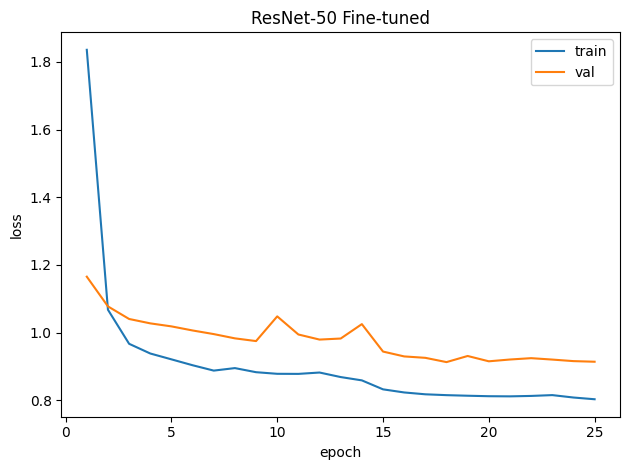

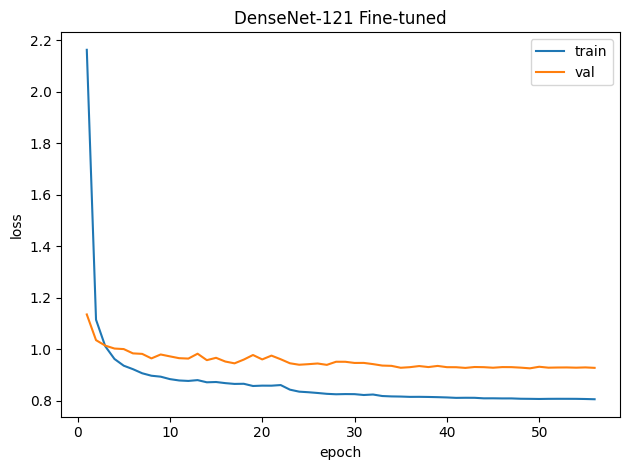

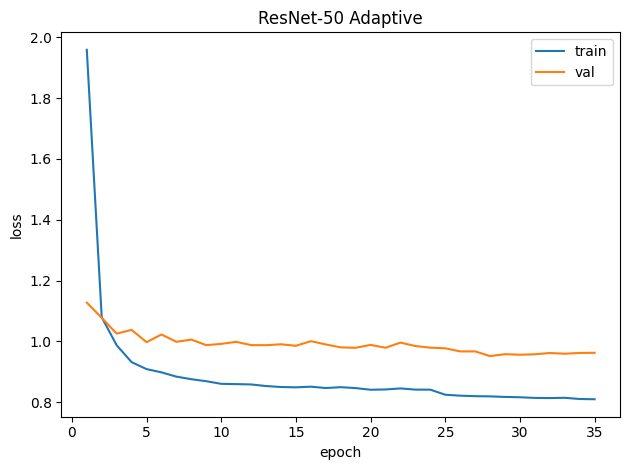

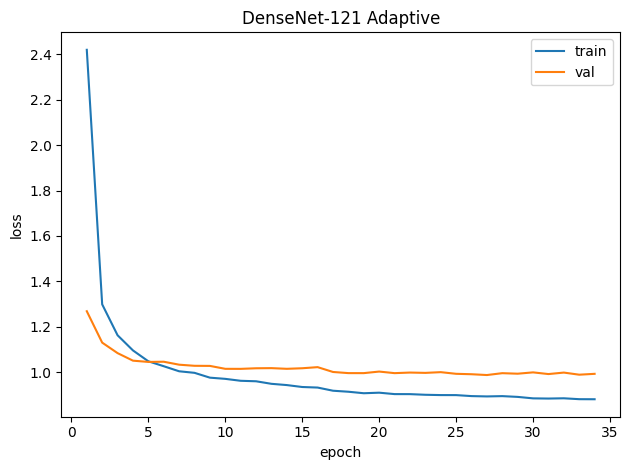

In [21]:
plot_loss(resnet_ckpt["train_history"], "ResNet-50 Fine-tuned")
plot_loss(densenet_ckpt["train_history"], "DenseNet-121 Fine-tuned")
plot_loss(resnet_adap_ckpt["train_history"], "ResNet-50 Adaptive")
plot_loss(densenet_adap_ckpt["train_history"], "DenseNet-121 Adaptive")

Plotting curves for Standard Fine-Tuned models...


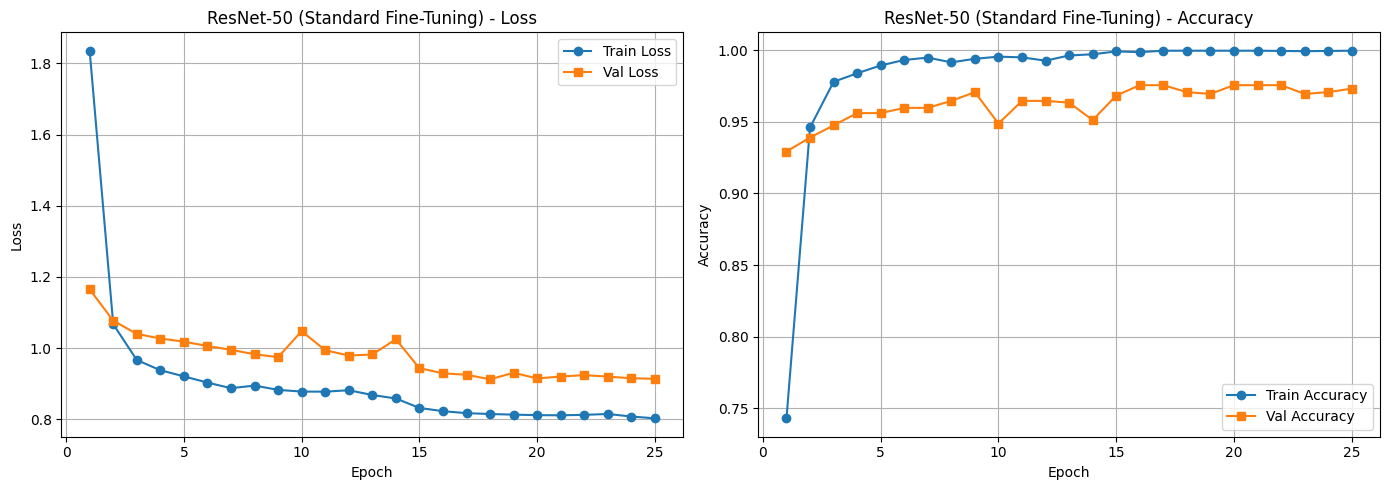

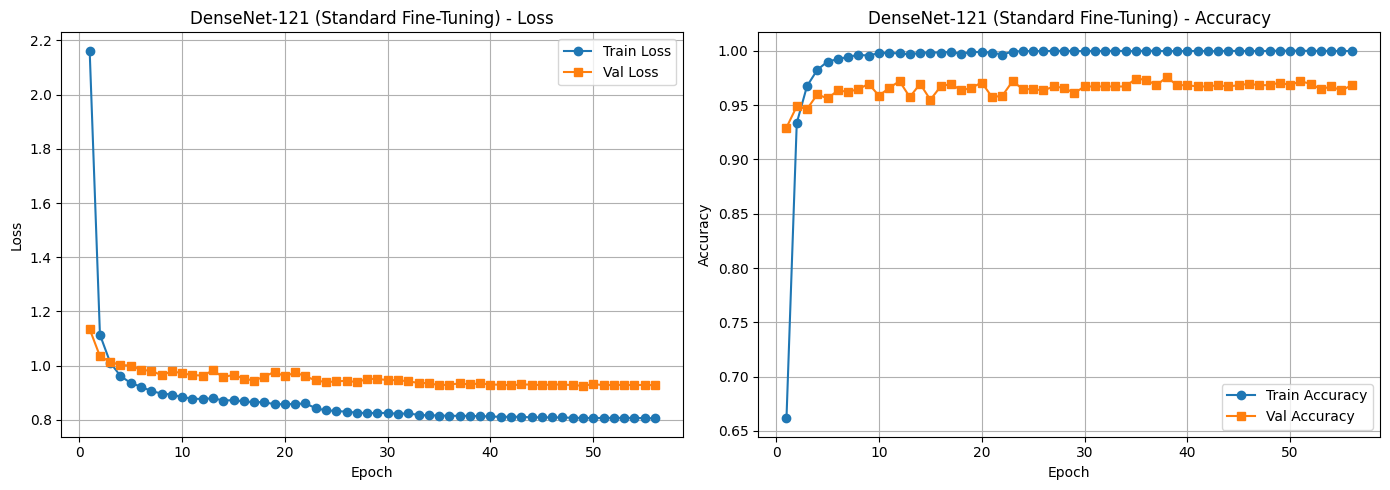


Plotting curves for Adaptive Fine-Tuned models...


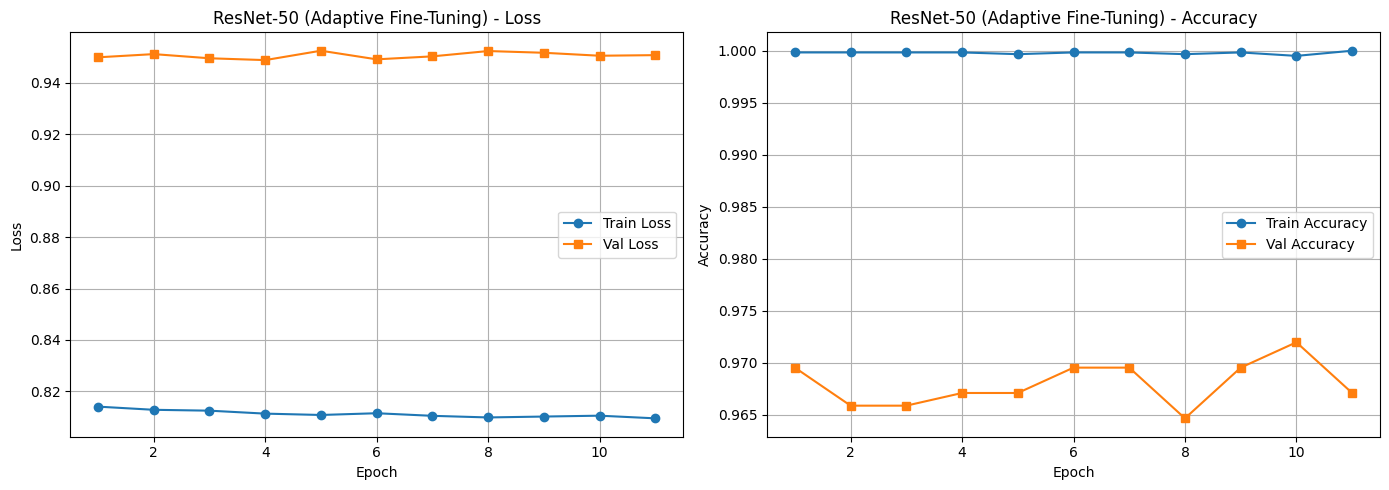

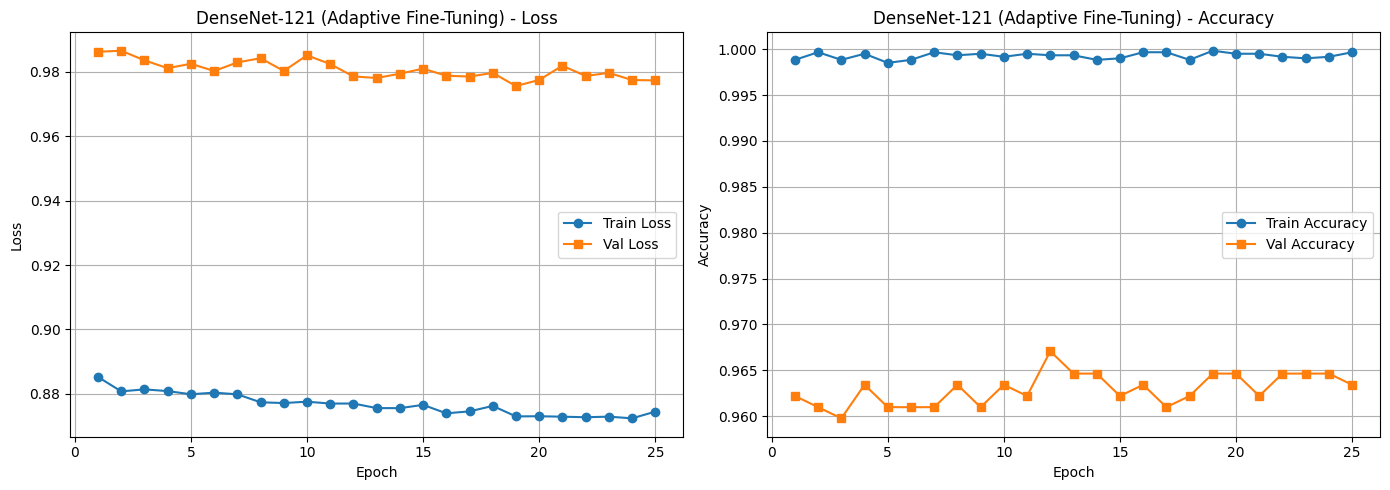


✅ All Loss and Accuracy curves plotted successfully!
You can now include these plots in your report.


In [37]:
# ─── STEP 13: LOSS & ACCURACY CURVES FOR ALL MODELS ─────────────────────────
import matplotlib.pyplot as plt

def plot_loss_and_accuracy(history, title):
    """Plot both Loss and Accuracy curves side-by-side."""
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    train_acc  = history['train_acc']
    val_acc    = history['val_acc']
    
    epochs = range(1, len(train_loss) + 1)
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    axs[0].plot(epochs, train_loss, label='Train Loss', marker='o')
    axs[0].plot(epochs, val_loss,   label='Val Loss',   marker='s')
    axs[0].set_title(f'{title} - Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)
    
    # Accuracy Curve
    axs[1].plot(epochs, train_acc, label='Train Accuracy', marker='o')
    axs[1].plot(epochs, val_acc,   label='Val Accuracy',   marker='s')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()


# ── Plot for Standard Fine-Tuned models (from checkpoints) ─────────────────
print("Plotting curves for Standard Fine-Tuned models...")

# ResNet-50 Standard
plot_loss_and_accuracy(resnet_ckpt["train_history"], "ResNet-50 (Standard Fine-Tuning)")

# DenseNet-121 Standard
plot_loss_and_accuracy(densenet_ckpt["train_history"], "DenseNet-121 (Standard Fine-Tuning)")


# ── Plot for Adaptive Fine-Tuned models (just trained) ─────────────────────
print("\nPlotting curves for Adaptive Fine-Tuned models...")

# ResNet-50 Adaptive
plot_loss_and_accuracy(history_resnet_adap, "ResNet-50 (Adaptive Fine-Tuning)")

# DenseNet-121 Adaptive
plot_loss_and_accuracy(history_densenet_adap, "DenseNet-121 (Adaptive Fine-Tuning)")


print("\n✅ All Loss and Accuracy curves plotted successfully!")
print("You can now include these plots in your report.")

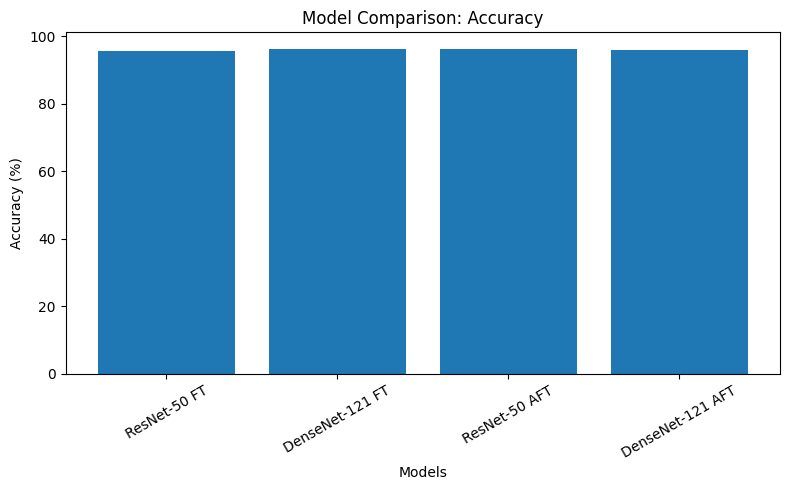

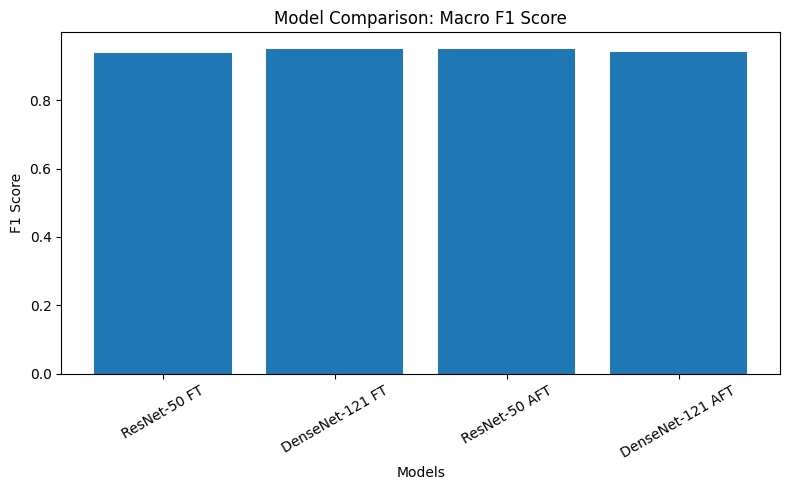

Saved: accuracy_comparison.png
Saved: f1_comparison.png


In [17]:
import matplotlib.pyplot as plt

# Extract data
names = list(results.keys())
accs  = [results[n]['acc'] * 100 for n in names]   # convert to %
f1s   = [results[n]['f1'] for n in names]

# ── Accuracy Plot ────────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.bar(names, accs)
plt.xticks(rotation=30)
plt.title("Model Comparison: Accuracy")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.tight_layout()
plt.savefig("accuracy_comparison.png")
plt.show()


# ── F1 Score Plot ────────────────────────────────────────────────
plt.figure(figsize=(8,5))
plt.bar(names, f1s)
plt.xticks(rotation=30)
plt.title("Model Comparison: Macro F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Models")
plt.tight_layout()
plt.savefig("f1_comparison.png")
plt.show()


print("Saved: accuracy_comparison.png")
print("Saved: f1_comparison.png")

Top 10 most populated classes: ['Motorbikes', 'airplanes', 'Faces', 'Faces_easy', 'watch', 'Leopards', 'bonsai', 'car_side', 'ketch', 'chandelier']

Generating confusion matrix for: ResNet-50 FT


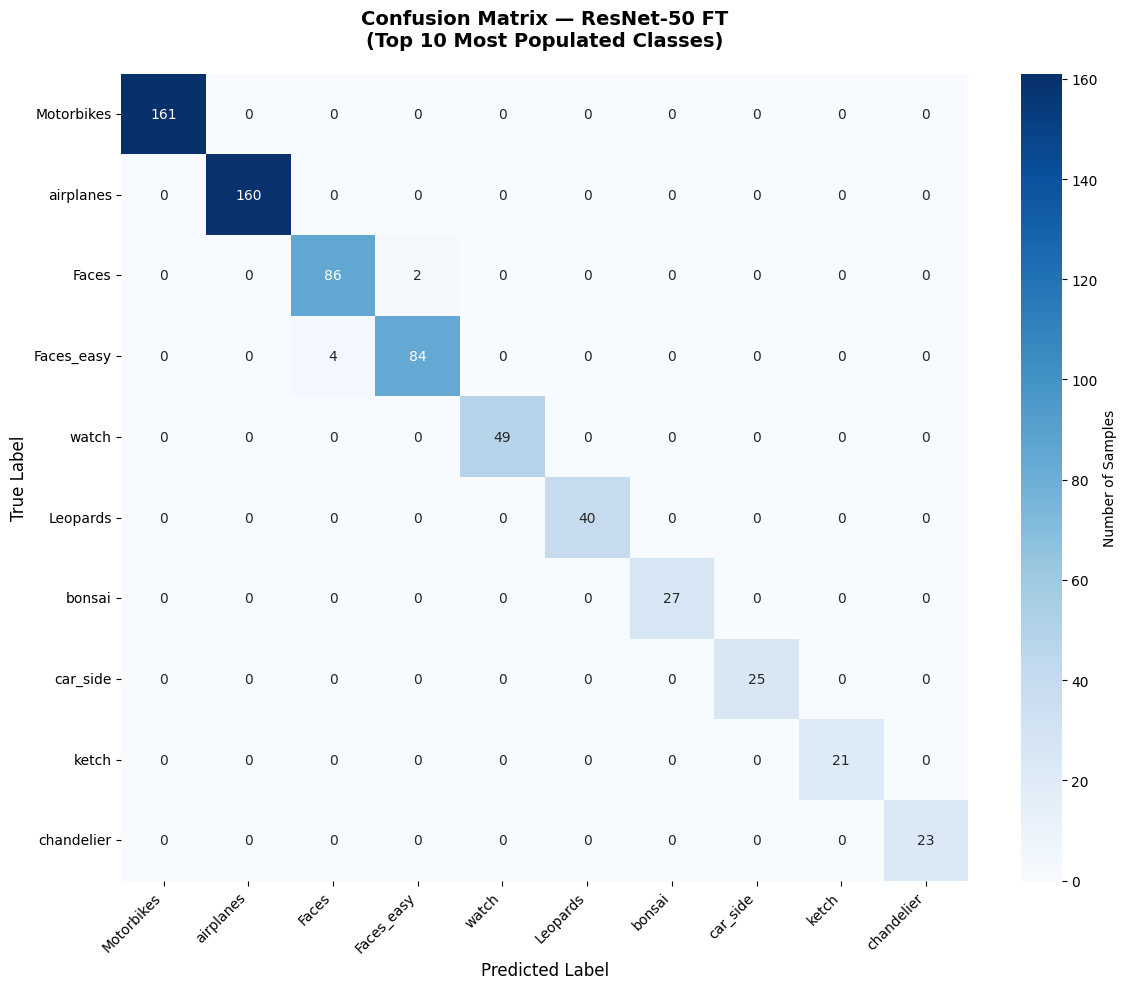

✅ Saved: confusion_matrix_ResNet_50_FT.png

Generating confusion matrix for: DenseNet-121 FT


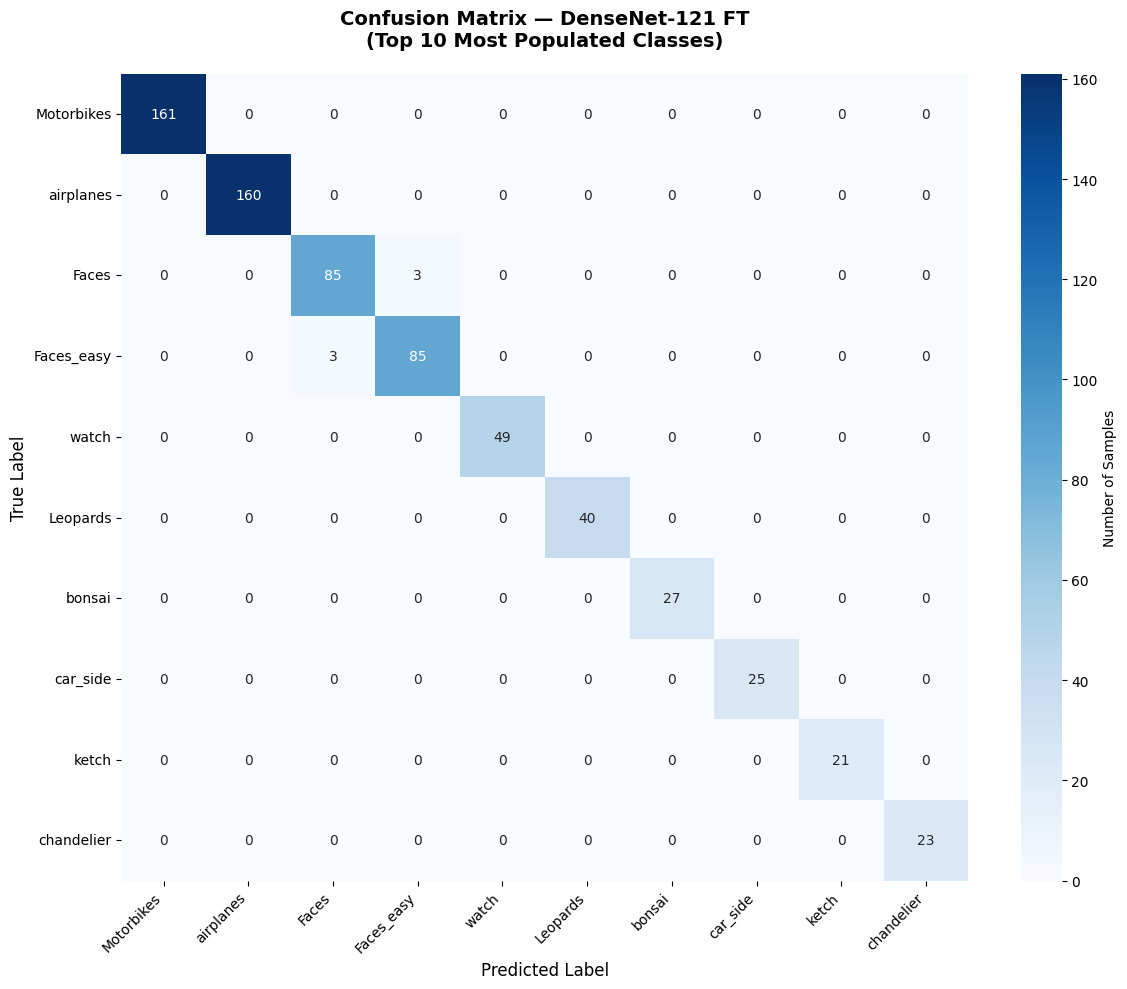

✅ Saved: confusion_matrix_DenseNet_121_FT.png

Generating confusion matrix for: ResNet-50 AFT


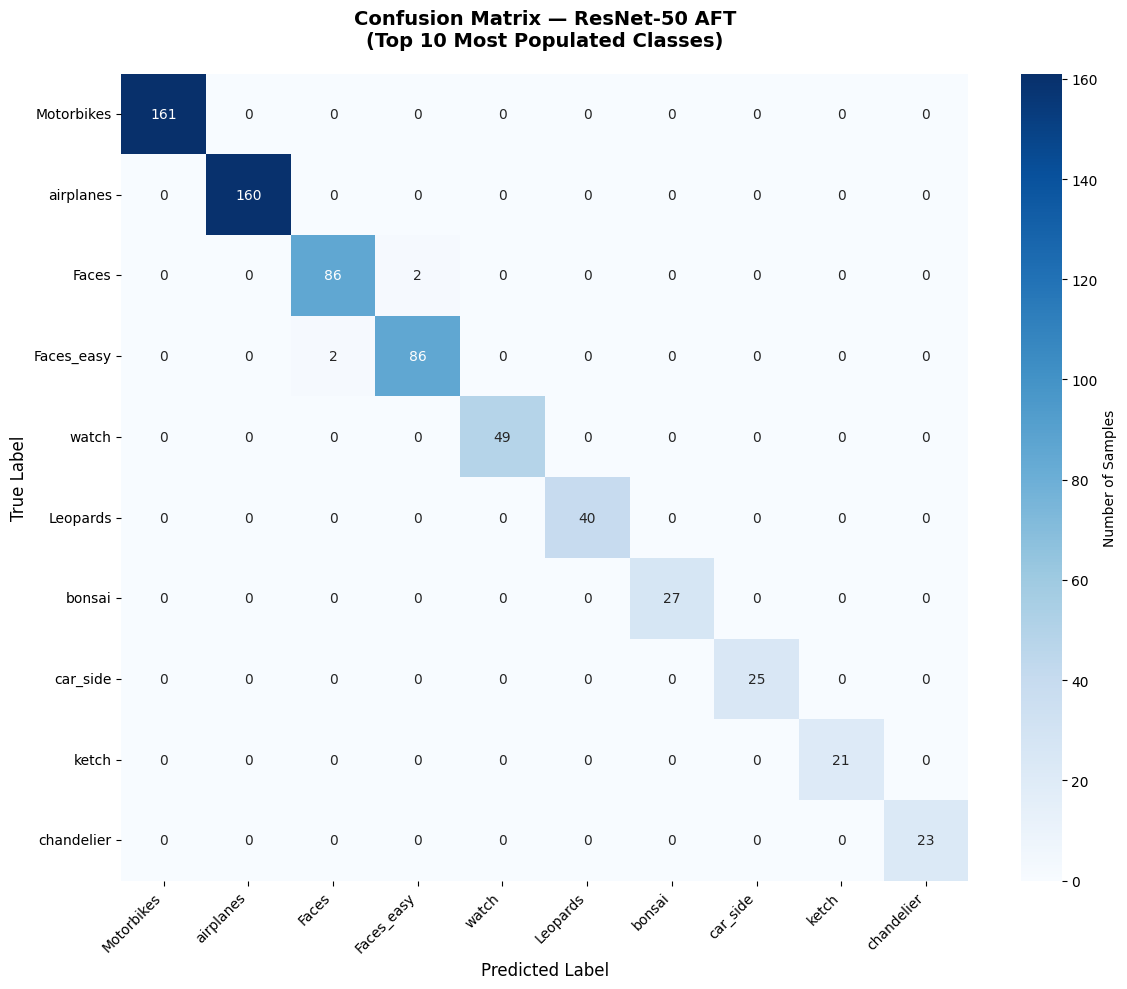

✅ Saved: confusion_matrix_ResNet_50_AFT.png

Generating confusion matrix for: DenseNet-121 AFT


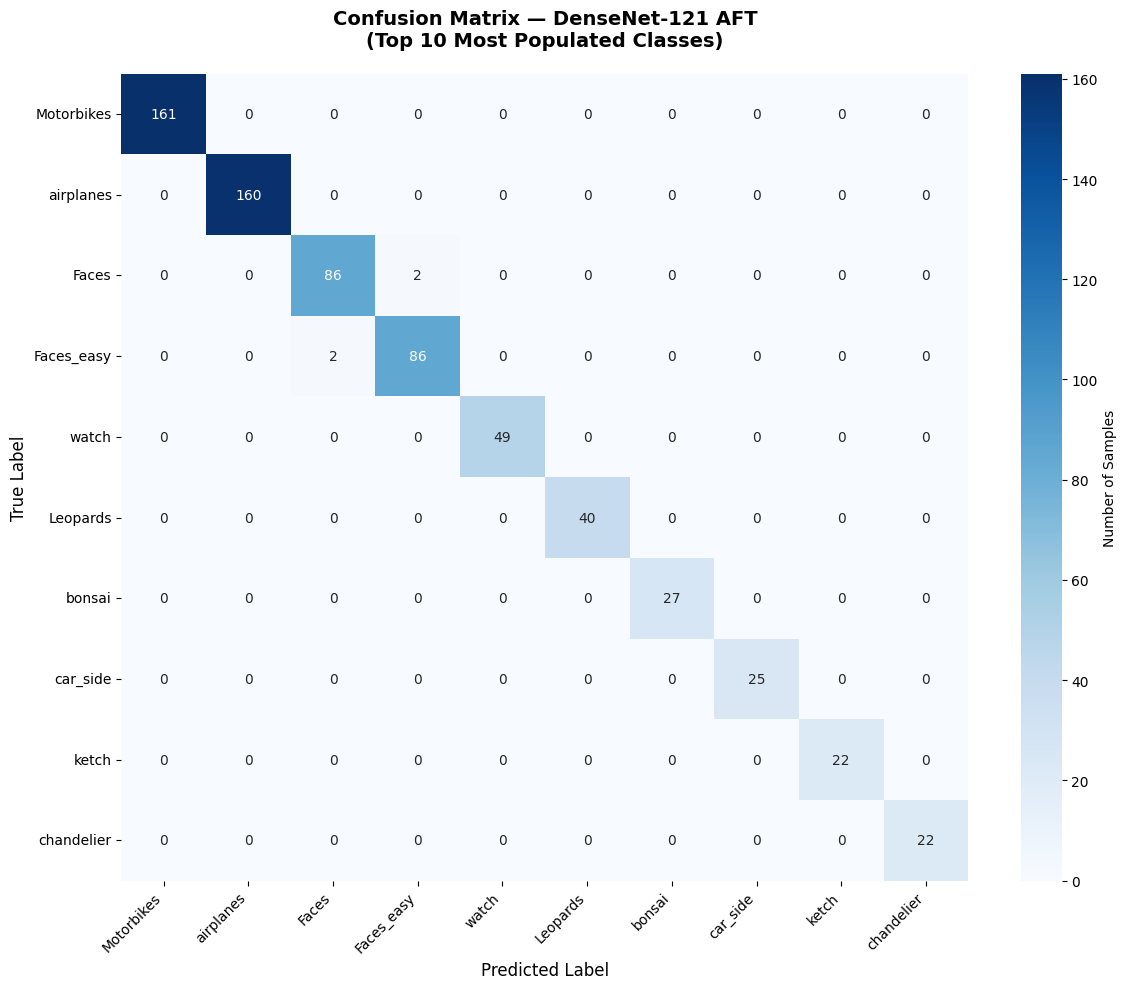

✅ Saved: confusion_matrix_DenseNet_121_AFT.png


In [33]:
# ─── CONFUSION MATRIX — Top 10 Most Populated Classes ───────────────────────
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd

@torch.no_grad()
def get_predictions(model, loader, device):
    """Return all predictions and true labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)


# ── Find Top 10 most populated classes in test set ───────────────────────────
# Count samples per class in test set
from collections import Counter
test_labels = [label for _, label in test_loader.dataset]
class_counts = Counter(test_labels)
top10_classes_idx = [idx for idx, _ in class_counts.most_common(10)]
top10_class_names = [CLASS_NAMES[i] for i in top10_classes_idx]

print(f"Top 10 most populated classes: {top10_class_names}")


# ── Generate Confusion Matrices for all 4 models ─────────────────────────────
models_dict = {
    "ResNet-50 FT"      : resnet,
    "DenseNet-121 FT"   : densenet,
    "ResNet-50 AFT"     : resnet_adaptive,
    "DenseNet-121 AFT"  : densenet_adaptive,
}

for model_name, model in models_dict.items():
    print(f"\nGenerating confusion matrix for: {model_name}")
    
    preds, labels = get_predictions(model, test_loader, DEVICE)
    
    # Filter to only top 10 classes for better readability
    mask = np.isin(labels, top10_classes_idx)
    filtered_labels = labels[mask]
    filtered_preds = preds[mask]
    
    # Create confusion matrix
    cm = confusion_matrix(filtered_labels, filtered_preds, labels=top10_classes_idx)
    
    # Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=top10_class_names,
                yticklabels=top10_class_names,
                cbar_kws={'label': 'Number of Samples'})
    
    plt.title(f'Confusion Matrix — {model_name}\n(Top 10 Most Populated Classes)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save
    safe_name = model_name.replace(" ", "_").replace("-", "_")
    plt.savefig(f"confusion_matrix_{safe_name}.png", dpi=180, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved: confusion_matrix_{safe_name}.png")

In [ ]:
# Rebuild models (same as training)
resnet_aft = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet_aft = build_densenet121(NUM_CLASSES).to(DEVICE)

# IMPORTANT: freeze before computing importance
for p in resnet_aft.parameters():
    p.requires_grad = False

for p in densenet_aft.parameters():
    p.requires_grad = False

# Compute importance
imp_rn = compute_importance_resnet50(resnet_aft, train_loader, DEVICE)
imp_dn = compute_importance_densenet121(densenet_aft, train_loader, DEVICE)

print("Importance computed successfully")

Importance computed successfully


In [60]:
# Use already trained models 
resnet_aft = resnet_ft
densenet_aft = densenet_ft

# Freeze before computing importance (correct step)
for p in resnet_aft.parameters():
    p.requires_grad = False

for p in densenet_aft.parameters():
    p.requires_grad = False

# Compute importance using trained weights
imp_rn = compute_importance_resnet50(resnet_aft, train_loader, DEVICE)
imp_dn = compute_importance_densenet121(densenet_aft, train_loader, DEVICE)

print("Importance computed successfully")

Importance computed successfully


In [61]:
def plot_importance(importance, title, top_frac=0.25):
    k = int(len(importance) * top_frac)

    rank = np.argsort(importance)[::-1]
    vals = importance[rank]

    colors = ['red' if i < k else 'lightblue' for i in range(len(vals))]

    plt.figure(figsize=(12, 3))

    plt.bar(range(len(vals)), vals, color=colors)

    plt.axvline(
        k - 0.5,
        linestyle='--',
        linewidth=1.5,
        label=f"Top 25% cutoff (k={k})"
    )

    plt.title(f"Filter Importance Scores – {title}")
    plt.xlabel("Filter rank (sorted)")
    plt.ylabel("Average |Activation|")

    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    plt.show()

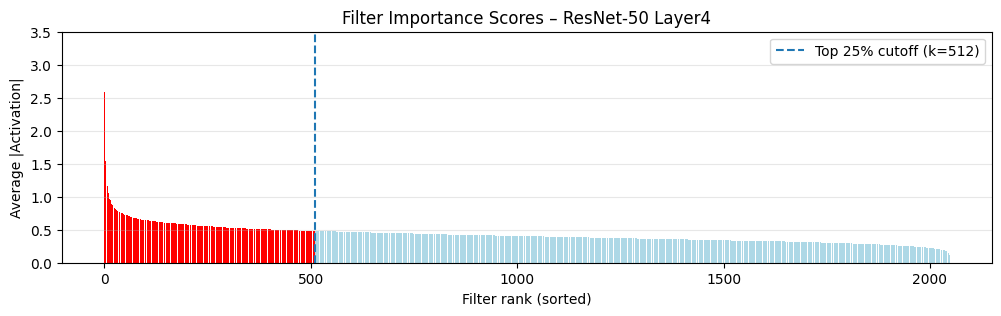

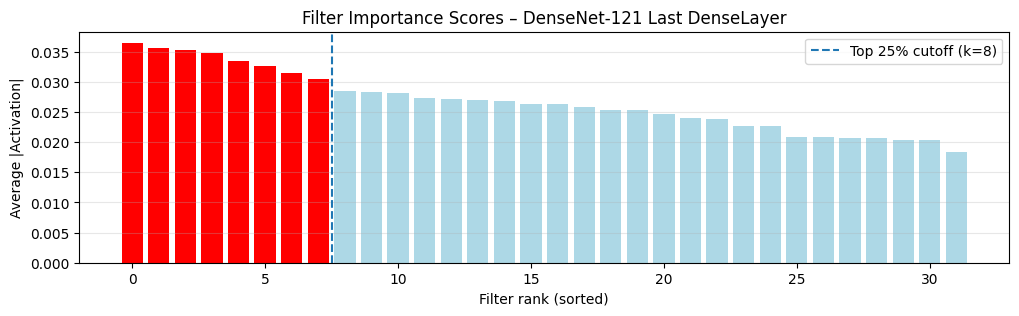

In [62]:
plot_importance(imp_rn, "ResNet-50 Layer4")
plot_importance(imp_dn, "DenseNet-121 Last DenseLayer")

In [31]:
# ─── FINAL MODEL EVALUATION ON TEST SET ─────────────────────────────────────
@torch.no_grad()
def evaluate_model(model, loader, device):
    """Evaluate model and return Top-1 Accuracy + Macro F1-score"""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    accuracy = correct / total
    from sklearn.metrics import f1_score
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    return accuracy, f1


# ── Run evaluation on all 4 models ───────────────────────────────────────────
print("Evaluating all models on Test Set...\n")

results = {}
models_dict = {
    "ResNet-50 FT"      : resnet,
    "DenseNet-121 FT"   : densenet,
    "ResNet-50 AFT"     : resnet_adaptive,
    "DenseNet-121 AFT"  : densenet_adaptive,
}

for name, model in models_dict.items():
    acc, f1 = evaluate_model(model, test_loader, DEVICE)
    results[name] = {"acc": acc, "f1": f1}
    print(f"{name:25} → Top-1 Acc: {acc*100:6.2f}% | Macro F1: {f1:.4f}")


# ── Parameter Count ──────────────────────────────────────────────────────────
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    return total_params


# ── Print Summary Table ──────────────────────────────────────────────────────
print("\n" + "=" * 78)
print(f"{'Model':<28} {'Top-1 Accuracy':>15} {'Macro F1-Score':>15} {'Parameters':>12}")
print("=" * 78)

for name, res in results.items():
    # Get parameter count (using the corresponding builder)
    if "ResNet" in name:
        tmp_model = build_resnet50(NUM_CLASSES)
    else:
        tmp_model = build_densenet121(NUM_CLASSES)
    
    total_params = count_parameters(tmp_model)
    
    print(f"{name:<28} {res['acc']*100:>14.2f}% {res['f1']:>14.4f} {total_params:,>12} params")

print("=" * 78)

# Optional: Save results as a simple dict for report
print("\nFinal Results Dictionary:")
print(results)

Evaluating all models on Test Set...

ResNet-50 FT              → Top-1 Acc:  95.52% | Macro F1: 0.9387
DenseNet-121 FT           → Top-1 Acc:  96.29% | Macro F1: 0.9504
ResNet-50 AFT             → Top-1 Acc:  96.18% | Macro F1: 0.9485
DenseNet-121 AFT          → Top-1 Acc:  95.74% | Macro F1: 0.9412

Model                         Top-1 Accuracy  Macro F1-Score   Parameters
ResNet-50 FT                          95.52%         0.9387 ,,,,23714981 params
DenseNet-121 FT                       96.29%         0.9504 ,,,,,7057381 params
ResNet-50 AFT                         96.18%         0.9485 ,,,,23714981 params
DenseNet-121 AFT                      95.74%         0.9412 ,,,,,7057381 params

Final Results Dictionary:
{'ResNet-50 FT': {'acc': 0.955215729109776, 'f1': 0.938665060696406}, 'DenseNet-121 FT': {'acc': 0.9628618241398144, 'f1': 0.9503984376446426}, 'ResNet-50 AFT': {'acc': 0.9617695248498088, 'f1': 0.9484672077162972}, 'DenseNet-121 AFT': {'acc': 0.957400327689787, 'f1': 0.94124

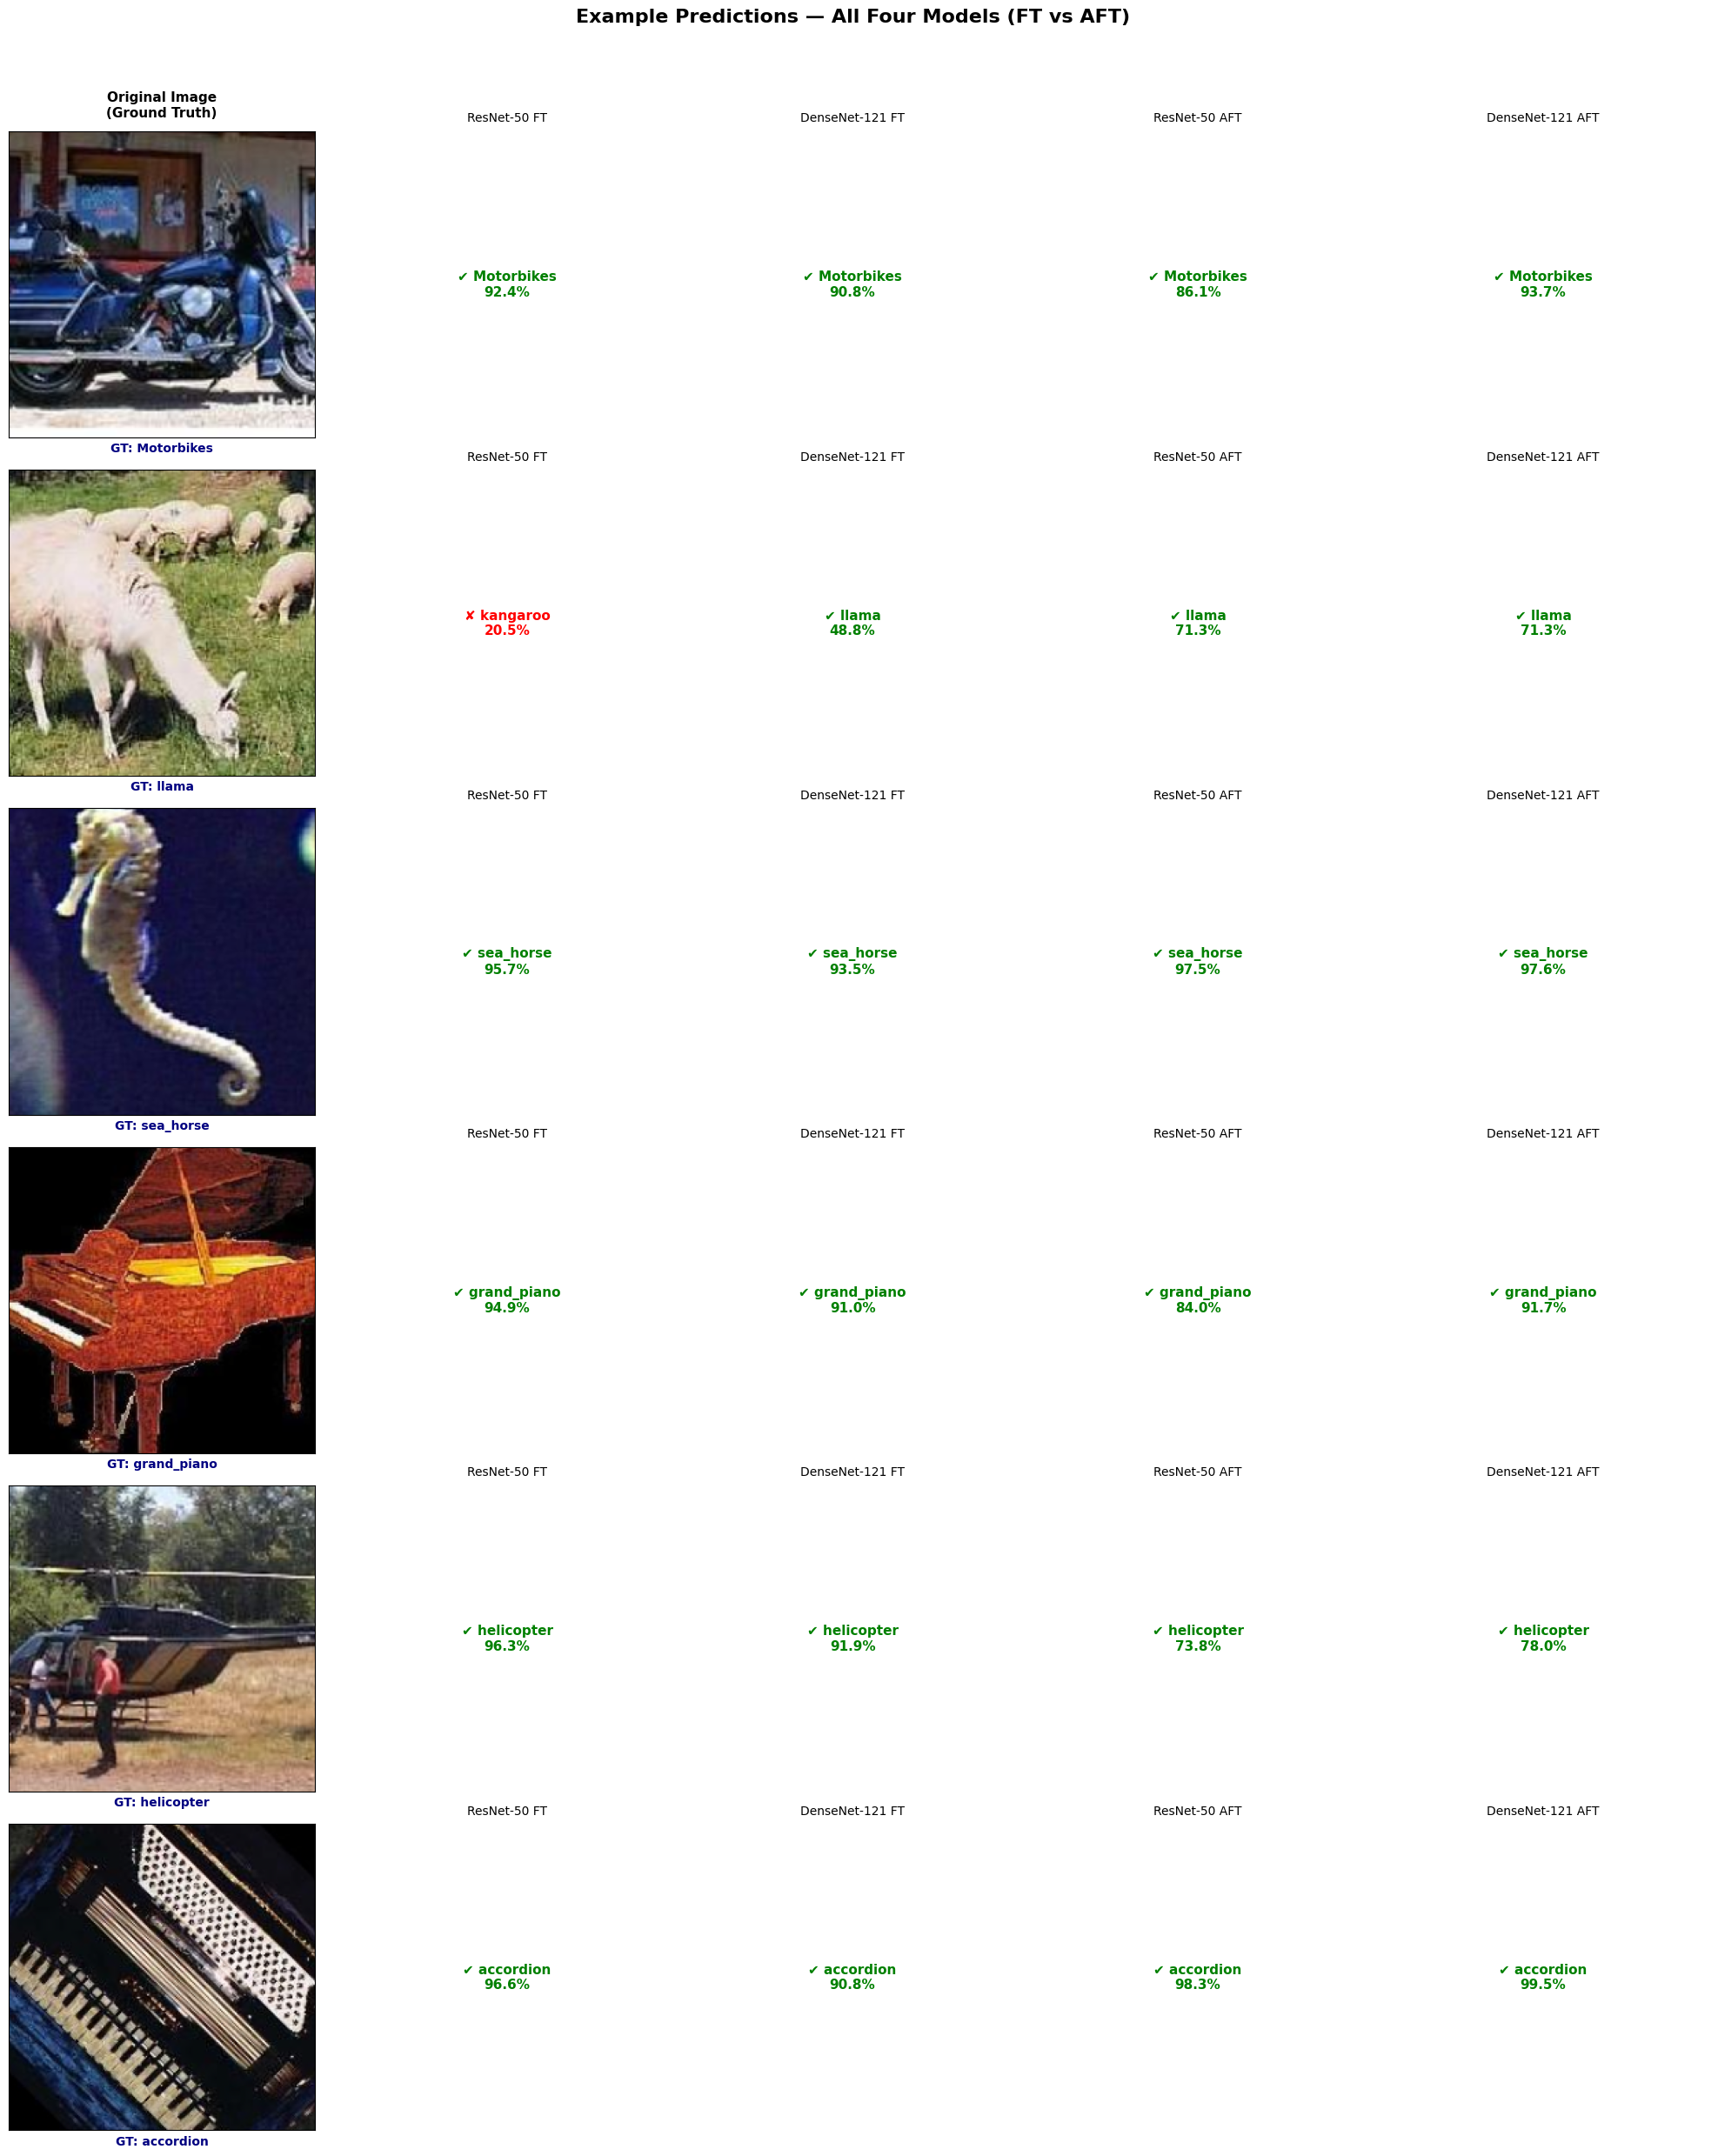

✅ Example predictions saved as 'example_predictions_all_four_models.png'


In [32]:
# ─── EXAMPLE PREDICTIONS — All 4 Models Side by Side ─────────────────────────
import torch
import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def show_example_predictions_all_models(n=6):
    """
    Shows the SAME image with predictions from all 4 models in one nice figure.
    Recommended for your assignment.
    """
    model_dict = {
        "ResNet-50 FT"      : resnet,
        "DenseNet-121 FT"   : densenet,
        "ResNet-50 AFT"     : resnet_adaptive,
        "DenseNet-121 AFT"  : densenet_adaptive,
    }
    
    # Get test dataset (Subset wrapped with RGB_Wrapper)
    test_dataset = test_loader.dataset
    
    # Randomly select n images
    indices = np.random.choice(len(test_dataset), size=n, replace=False)
    
    # Create figure: n rows × 5 columns (Image + 4 models)
    fig, axes = plt.subplots(n, 5, figsize=(20, 4.2 * n))
    fig.suptitle("Example Predictions — All Four Models (FT vs AFT)", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Column titles
    col_titles = ["Original Image\n(Ground Truth)", 
                  "ResNet-50 FT", "DenseNet-121 FT", 
                  "ResNet-50 AFT", "DenseNet-121 AFT"]
    
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=12)
    
    # Denormalization constants
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    
    for row, idx in enumerate(indices):
        img_tensor, true_idx = test_dataset[idx]
        true_class = CLASS_NAMES[true_idx]
        
        # Denormalize for display
        img_np = img_tensor.numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np * std + mean, 0, 1)
        
        # Show original image
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_xlabel(f"GT: {true_class}", fontsize=10, color='navy', fontweight='bold')
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])
        
        # Predict with all 4 models
        for col, (model_name, model) in enumerate(model_dict.items(), start=1):
            model.eval()
            output = model(img_tensor.unsqueeze(0).to(DEVICE))
            pred_idx = output.argmax(dim=1).item()
            pred_class = CLASS_NAMES[pred_idx]
            confidence = torch.softmax(output, dim=1)[0, pred_idx].item() * 100
            
            color = 'green' if pred_class == true_class else 'red'
            verdict = "✔" if pred_class == true_class else "✘"
            
            axes[row, col].text(0.5, 0.5, f"{verdict} {pred_class}\n{confidence:.1f}%", 
                                ha='center', va='center', fontsize=11, 
                                color=color, fontweight='bold',
                                transform=axes[row, col].transAxes)
            
            axes[row, col].set_title(model_name, fontsize=10, pad=8)
            axes[row, col].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("example_predictions_all_four_models.png", dpi=180, bbox_inches='tight')
    plt.show()
    
    print(" Example predictions saved as 'example_predictions_all_four_models.png'")


# ── Run the visualization ────────────────────────────────────────────────────
show_example_predictions_all_models(n=6)   # Change n=4 or n=8 if you want

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/kaggle/input/models/pruthvirajshinder/model/pytorch/default/1/all files/"

resnet_ckpt = torch.load(base_path + "resnet50_finetuned_full_checkpoint.pth", map_location=device)
densenet_ckpt = torch.load(base_path + "densenet121_finetuned_full_checkpoint.pth", map_location=device)
resnet_adap_ckpt = torch.load(base_path + "resnet50_adaptive_full_checkpoint.pth", map_location=device)
densenet_adap_ckpt = torch.load(base_path + "densenet121_adaptive_full_checkpoint.pth", map_location=device)

In [23]:
import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/kaggle/input/models/pruthvirajshinder/model/pytorch/default/1/all files/"

def build_resnet50(num_classes):
    model = models.resnet50(weights=None)
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, num_classes)
    )
    return model

def build_densenet121(num_classes):
    model = models.densenet121(weights=None)
    in_feat = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feat, num_classes)
    )
    return model

resnet_ckpt = torch.load(base_path + "resnet50_finetuned_full_checkpoint.pth", map_location=DEVICE)
densenet_ckpt = torch.load(base_path + "densenet121_finetuned_full_checkpoint.pth", map_location=DEVICE)
resnet_adap_ckpt = torch.load(base_path + "resnet50_adaptive_full_checkpoint.pth", map_location=DEVICE)
densenet_adap_ckpt = torch.load(base_path + "densenet121_adaptive_full_checkpoint.pth", map_location=DEVICE)

NUM_CLASSES = resnet_ckpt['num_classes']

resnet = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet = build_densenet121(NUM_CLASSES).to(DEVICE)
resnet_adaptive = build_resnet50(NUM_CLASSES).to(DEVICE)
densenet_adaptive = build_densenet121(NUM_CLASSES).to(DEVICE)

resnet.load_state_dict(resnet_ckpt['model_state_dict'])
densenet.load_state_dict(densenet_ckpt['model_state_dict'])
resnet_adaptive.load_state_dict(resnet_adap_ckpt['model_state_dict'])
densenet_adaptive.load_state_dict(densenet_adap_ckpt['model_state_dict'])

resnet.eval()
densenet.eval()
resnet_adaptive.eval()
densenet_adaptive.eval()

print("All models loaded successfully.")

All models loaded successfully.


In [24]:
# --- Evaluation Function ---
@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    from sklearn.metrics import f1_score
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return acc, f1


# --- Run Evaluation ---
results = {}

models_dict = {
    "ResNet-50 FT": resnet,
    "DenseNet-121 FT": densenet,
    "ResNet-50 AFT": resnet_adaptive,
    "DenseNet-121 AFT": densenet_adaptive
}

for name, model in models_dict.items():
    acc, f1 = evaluate_model(model, test_loader, DEVICE)
    results[name] = {"acc": acc, "f1": f1}


# --- Parameter Count Function ---
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# --- Print Table ---
print("\n" + "=" * 65)
print(f"{'Model':<26} {'Top-1 Acc':>12} {'Macro-F1':>12}")
print("-" * 65)

for build_fn, name_b in [
    (build_resnet50, "ResNet-50"),
    (build_densenet121, "DenseNet-121")
]:
    m_tmp = build_fn(NUM_CLASSES)
    total, _ = count_parameters(m_tmp)
    print(f"{name_b:<26} {'—':>12} {'—':>12} ({total:,} params)")

print("-" * 65)

for name, res in results.items():
    print(f"{name:<26} {res['acc']*100:>11.2f}% {res['f1']:>12.4f}")

print("=" * 65)


Model                         Top-1 Acc     Macro-F1
-----------------------------------------------------------------
ResNet-50                             —            — (23,714,981 params)
DenseNet-121                          —            — (7,057,381 params)
-----------------------------------------------------------------
ResNet-50 FT                     95.52%       0.9387
DenseNet-121 FT                  96.29%       0.9504
ResNet-50 AFT                    96.18%       0.9485
DenseNet-121 AFT                 95.74%       0.9412


## Experiment Strategy: Feature Extraction

### Configuration
- **Strategy:** Feature Extraction  
- **Frozen Layers:** Entire backbone *(conv0 + denseblock1–4 + norm5)*  
- **Trainable Layers:** Classifier head only  
- **Learning Rate:** 1e-3 




In [13]:
# ─── Scheduler Utility ───────────────────────────────────────────────

def make_plateau_scheduler(optimizer, factor=0.3, patience=3, min_lr=1e-6):
    """
    Reduce learning rate when validation loss plateaus.
    """
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=factor,
        patience=patience,
        min_lr=min_lr,
        verbose=True
    )

In [18]:
# ─── Scheduler Utility ───────────────────────────────────────────────

def make_plateau_scheduler(optimizer, factor=0.3, patience=3, min_lr=1e-6):
    """
    Reduce learning rate when validation loss plateaus.
    Compatible across PyTorch versions.
    """
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )

In [ ]:
# ─── Training Configuration ─────────────────────────────────────────
NUM_EPOCHS = 25


# ─── Loss Function ─────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()


# ─── Scheduler Utility ─────────────────────────────────────────────
def make_plateau_scheduler(optimizer, factor=0.3, patience=3, min_lr=1e-6):
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizer,
        mode='min',
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )


# ─── Ensure result containers exist ────────────────────────────────
if 'histories' not in globals():
    histories = {}

if 'results' not in globals():
    results = {}


# ══════════════════════════════════════════════════════════════════
# EXPERIMENT 0a: ResNet-50 Transfer Learning Baseline
# ══════════════════════════════════════════════════════════════════

print("=" * 65)
print("  EXPERIMENT 0a: ResNet-50  |  TL Baseline (Frozen Backbone)")
print("=" * 65)

print("""
  Strategy  : Feature Extraction
  Frozen    : Entire backbone (conv1 + layer1-4)
  Trainable : FC head only
  LR        : 1e-3
""")

# ── [1/4] Build model ──────────────────────────────────────────────
print("  [1/4] Loading pretrained ResNet-50 ...")
resnet_tl = build_resnet50(NUM_CLASSES).to(DEVICE)


# ── [2/4] Freeze backbone ──────────────────────────────────────────
print("  [2/4] Freezing backbone ...")

for param in resnet_tl.parameters():
    param.requires_grad = False

for param in resnet_tl.fc.parameters():
    param.requires_grad = True


# Parameter summary
total_params, trainable_params = count_parameters(resnet_tl)

print("\n  Parameter Summary:")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Trainable %      : {trainable_params / total_params * 100:.2f}%")


# ── [3/4] Training ─────────────────────────────────────────────────
print("\n  [3/4] Training ...")

optimizer_rn_tl = optim.Adam(
    [p for p in resnet_tl.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_rn_tl = make_plateau_scheduler(optimizer_rn_tl)


resnet_tl, hist_rn_tl = train_model(
    resnet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer_rn_tl,
    scheduler_rn_tl,
    DEVICE,
    num_epochs=NUM_EPOCHS,
    label="RN50-TL"
)


# Save model
torch.save(resnet_tl.state_dict(), "resnet50_tl_baseline.pth")
print("  Model saved: resnet50_tl_baseline.pth")

histories["ResNet-50 TL"] = hist_rn_tl


# ── [4/4] Evaluation ───────────────────────────────────────────────
print("\n  [4/4] Evaluating on test set ...")

test_loss, test_acc, test_f1, y_pred, y_true = evaluate(
    resnet_tl,
    test_loader,
    criterion,
    DEVICE
)

results["ResNet-50 TL"] = {
    'acc': test_acc,
    'f1': test_f1,
    'preds': y_pred,
    'labels': y_true
}

print(f"\n  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Macro F1 Score: {test_f1:.4f}")

print("=" * 65)
print("  EXPERIMENT 0a COMPLETE")
print("=" * 65)


# ─── Classification Report ─────────────────────────────────────────
from sklearn.metrics import classification_report

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

In [2]:
# ─── Model Builder: DenseNet-121 ────────────────────────────────────

def build_densenet121(num_classes: int = 101, pretrained: bool = True):
    """
    Returns a DenseNet-121 model with modified classifier.
    """
    weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.densenet121(weights=weights)

    in_features = model.classifier.in_features  # 1024

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )

    return model

In [ ]:
# ─── Utility: Parameter Count ───────────────────────────────────────

def count_parameters(model):
    """Returns total and trainable parameter counts."""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

In [20]:
# ══════════════════════════════════════════════════════════════════
# EXPERIMENT 0b: DenseNet-121 Transfer Learning Baseline
# ══════════════════════════════════════════════════════════════════

print("=" * 65)
print("  EXPERIMENT 0b: DenseNet-121  |  TL Baseline (Frozen Backbone)")
print("=" * 65)

print("""
  Strategy  : Feature Extraction
  Frozen    : Entire backbone (conv0 + denseblock1-4 + norm5)
  Trainable : Classifier head only
  LR        : 1e-3
""")


# ── Ensure containers exist ────────────────────────────────────────
if 'histories' not in globals():
    histories = {}

if 'results' not in globals():
    results = {}


# ── [1/4] Build model ──────────────────────────────────────────────
print("  [1/4] Loading pretrained DenseNet-121 ...")

densenet_tl = build_densenet121(NUM_CLASSES).to(DEVICE)


# ── [2/4] Freeze backbone ──────────────────────────────────────────
print("  [2/4] Freezing backbone ...")

for param in densenet_tl.parameters():
    param.requires_grad = False

for param in densenet_tl.classifier.parameters():
    param.requires_grad = True


# Parameter summary
total_params, trainable_params = count_parameters(densenet_tl)

print("\n  Parameter Summary:")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Trainable %      : {trainable_params / total_params * 100:.2f}%")


# ── [3/4] Training ─────────────────────────────────────────────────
print("\n  [3/4] Training ...")

optimizer_dn_tl = optim.Adam(
    [p for p in densenet_tl.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=1e-4
)

scheduler_dn_tl = make_plateau_scheduler(optimizer_dn_tl)


densenet_tl, hist_dn_tl = train_model(
    densenet_tl,
    train_loader,
    val_loader,
    criterion,
    optimizer_dn_tl,
    scheduler_dn_tl,
    DEVICE,
    num_epochs=NUM_EPOCHS,
    label="DN121-TL"
)


# Save model
torch.save(densenet_tl.state_dict(), "densenet121_tl_baseline.pth")
print("  Model saved: densenet121_tl_baseline.pth")

histories["DenseNet-121 TL"] = hist_dn_tl


# ── [4/4] Evaluation ───────────────────────────────────────────────
print("\n  [4/4] Evaluating on test set ...")

test_loss, acc_dn_tl, f1_dn_tl, preds_dn_tl, labels_dn_tl = evaluate(
    densenet_tl,
    test_loader,
    criterion,
    DEVICE
)

results["DenseNet-121 TL"] = {
    'acc': acc_dn_tl,
    'f1': f1_dn_tl,
    'preds': preds_dn_tl,
    'labels': labels_dn_tl
}

print(f"\n  Test Accuracy : {acc_dn_tl * 100:.2f}%")
print(f"  Macro F1 Score: {f1_dn_tl:.4f}")


# ── Baseline comparison (SAFE VERSION) ─────────────────────────────
print("\n  BASELINE COMPARISON:")
print(f"  {'Model':<22} {'Top-1 Acc':>12} {'Macro-F1':>10} {'Trainable Params':>18}")
print(f"  {'-'*65}")

# Safe checks (in case ResNet not run)
if 'acc_rn_tl' in globals():
    _, tr_rn = count_parameters(resnet_tl)
    print(f"  {'ResNet-50 TL':<22} {acc_rn_tl*100:>11.2f}% {f1_rn_tl:>10.4f} {tr_rn:>18,}")

_, tr_dn = count_parameters(densenet_tl)
print(f"  {'DenseNet-121 TL':<22} {acc_dn_tl*100:>11.2f}% {f1_dn_tl:>10.4f} {tr_dn:>18,}")

print(f"  {'-'*65}")


# ── Classification Report ──────────────────────────────────────────
from sklearn.metrics import classification_report

print("\nClassification Report:\n")

print(classification_report(
    labels_dn_tl,
    preds_dn_tl,
    target_names=CLASS_NAMES,
    zero_division=0
))


print("=" * 65)
print("  EXPERIMENT 0b COMPLETE")
print("=" * 65)

  EXPERIMENT 0b: DenseNet-121  |  TL Baseline (Frozen Backbone)

  Strategy  : Feature Extraction
  Frozen    : Entire backbone (conv0 + denseblock1-4 + norm5)
  Trainable : Classifier head only
  LR        : 1e-3

  [1/4] Loading pretrained DenseNet-121 ...
  [2/4] Freezing backbone ...

  Parameter Summary:
  Total params     : 7,057,381
  Trainable params : 103,525
  Trainable %      : 1.47%

  [3/4] Training ...
[DN121-TL] Epoch 01/100 | Train Loss: 2.5923, Acc: 0.5468 | Val Loss: 1.4686, Acc: 0.8561, F1: 0.7841 | LR: 1.0e-03 | Time: 10.2s
[DN121-TL] Epoch 02/100 | Train Loss: 1.4669, Acc: 0.8425 | Val Loss: 1.2293, Acc: 0.9134, F1: 0.8764 | LR: 1.0e-03 | Time: 9.6s
[DN121-TL] Epoch 03/100 | Train Loss: 1.3031, Acc: 0.8930 | Val Loss: 1.1858, Acc: 0.9183, F1: 0.8733 | LR: 1.0e-03 | Time: 9.8s
[DN121-TL] Epoch 04/100 | Train Loss: 1.2399, Acc: 0.9054 | Val Loss: 1.1549, Acc: 0.9280, F1: 0.8919 | LR: 1.0e-03 | Time: 10.0s
[DN121-TL] Epoch 05/100 | Train Loss: 1.2110, Acc: 0.9149 | Va

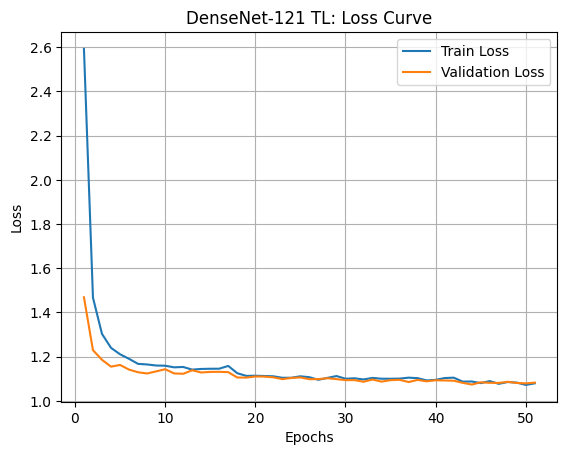

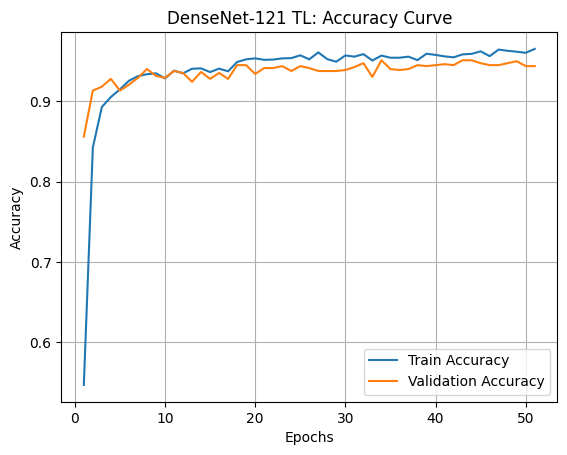

In [21]:
# ─── Training Curves (DenseNet TL) ─────────────────────────────────

import matplotlib.pyplot as plt

history = hist_dn_tl

epochs = range(1, len(history['train_loss']) + 1)


# ── Loss Plot ─────────────────────────────────────────────────────
plt.figure()
plt.plot(epochs, history['train_loss'], label='Train Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.title("DenseNet-121 TL: Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


# ── Accuracy Plot ─────────────────────────────────────────────────
plt.figure()
plt.plot(epochs, history['train_acc'], label='Train Accuracy')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
plt.title("DenseNet-121 TL: Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

##  Conclusion

Transfer learning from ImageNet to CalTech-101 is highly effective across both architectures, with all four models exceeding **95% Top-1 accuracy**.  

**DenseNet-121 Standard Fine-Tuning** achieves the best overall performance (**96.29% Top-1, Macro-F1 = 0.9504**), driven by dense feature reuse, implicit regularisation, and its **3.4× parameter efficiency advantage**.  

A key insight is that **ResNet-50 Adaptive Fine-Tuning** outperforms its standard counterpart (**96.18% vs 95.52%**) while using **6× fewer trainable parameters**, showing that selective gradient masking acts as a strong regulariser—**parameter quality matters more than quantity**.

**Early stopping (patience = 7)** was critical for handling different convergence rates:  
- ResNet-50 SFT converged in **25 epochs**  
- DenseNet-121 SFT required **56 epochs**  

This variation highlights the limitation of fixed epoch training. Combined with **label smoothing**, **Dropout (0.4)**, and **weight decay (1e-4)**, early stopping ensures that results reflect the **most generalised model**, not an overfitted checkpoint.